<a href="https://colab.research.google.com/github/JannatLima/earthquake-blast-classification-ml/blob/main/earthquake_blast_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#-------Cell 1---------#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

In [2]:
#-------Cell 2---------#
#-----Retrieve quarry blast events from USGS-----#

qb_url = (
    "https://earthquake.usgs.gov/fdsnws/event/1/query?"
    "format=csv"
    "&starttime=2000-01-01"
    "&endtime=2024-12-31"
    "&minmagnitude=1.0"
    "&maxmagnitude=4.5"
    "&eventtype=quarry%20blast"
    "&limit=20000"
)

quarry_df = pd.read_csv(qb_url)

quarry_df['Type'] = 'Quarry Blast'

print("Quarry blast events retrieved:", len(quarry_df))
print("\nColumns:")
print(quarry_df.columns.tolist())

print("\nDate range:")
print(quarry_df['time'].min(), "to", quarry_df['time'].max())


Quarry blast events retrieved: 20000

Columns:
['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type', 'horizontalError', 'depthError', 'magError', 'magNst', 'status', 'locationSource', 'magSource', 'Type']

Date range:
2004-02-03T19:57:42.720Z to 2024-12-30T21:59:10.160Z


In [ ]:
# Replace df with the actual name of your final DataFrame

print("Total rows:", df.shape[0])
print("Total columns:", df.shape[1])

print("\nAll columns:")
for i, column in enumerate(df.columns, start=1):
    print(i, column)

In [3]:
#-------Cell 3A---------#
#-----Audit quarry-blast yearly distribution-----#

quarry_df['event_year'] = pd.to_datetime(
    quarry_df['time'], utc=True
).dt.year

print("Quarry blasts by year:")
print(quarry_df['event_year'].value_counts().sort_index())

print("\nTotal:")
print(len(quarry_df))

print("\nYear range:")
print(quarry_df['event_year'].min(), "to", quarry_df['event_year'].max())

Quarry blasts by year:
event_year
2004     779
2005     851
2006     861
2007     933
2008     945
2009     711
2010     680
2011     730
2012     787
2013     821
2014     697
2015     947
2016    1061
2017    1014
2018     938
2019     987
2020    1137
2021    1404
2022    1202
2023    1166
2024    1349
Name: count, dtype: int64

Total:
20000

Year range:
2004 to 2024


In [4]:
#-------Cell 3---------#
#-----Retrieve and reproducibly sample earthquake events-----#

import time

RANDOM_SEED = 42
EQ_PER_YEAR = 800

years = list(range(2000, 2025))

eq_frames = []

for year in years:

    url = (
        f"https://earthquake.usgs.gov/fdsnws/event/1/query?"
        f"format=csv"
        f"&starttime={year}-01-01"
        f"&endtime={year}-12-31"
        f"&minmagnitude=1.0"
        f"&maxmagnitude=4.5"
        f"&eventtype=earthquake"
        f"&limit=20000"
    )

    try:
        chunk = pd.read_csv(url)

        print(f"{year}: {len(chunk)} qualifying earthquakes retrieved")

        # Reproducible random sampling within each year
        if len(chunk) >= EQ_PER_YEAR:
            chunk = chunk.sample(
                n=EQ_PER_YEAR,
                random_state=RANDOM_SEED
            )
        else:
            print(
                f"WARNING: {year} has only {len(chunk)} "
                f"qualifying earthquakes."
            )

        eq_frames.append(chunk)

        print(f"{year}: {len(chunk)} selected")

    except Exception as e:
        print(f"{year}: failed ({e})")

    time.sleep(1)  # Be polite to the USGS server


earthquake_df = pd.concat(eq_frames, ignore_index=True)

earthquake_df['Type'] = 'Earthquake'

print("\n" + "=" * 60)
print("Earthquake sampling completed")
print("=" * 60)

print("Total earthquake events selected:", len(earthquake_df))

print("\nEvents by year:")
print(
    pd.to_datetime(
        earthquake_df['time'],
        utc=True
    ).dt.year.value_counts().sort_index()
)

2000: 20000 qualifying earthquakes retrieved
2000: 800 selected
2001: 20000 qualifying earthquakes retrieved
2001: 800 selected
2002: 20000 qualifying earthquakes retrieved
2002: 800 selected
2003: 20000 qualifying earthquakes retrieved
2003: 800 selected
2004: 20000 qualifying earthquakes retrieved
2004: 800 selected
2005: 20000 qualifying earthquakes retrieved
2005: 800 selected
2006: 20000 qualifying earthquakes retrieved
2006: 800 selected
2007: 20000 qualifying earthquakes retrieved
2007: 800 selected
2008: 20000 qualifying earthquakes retrieved
2008: 800 selected
2009: 20000 qualifying earthquakes retrieved
2009: 800 selected
2010: 20000 qualifying earthquakes retrieved
2010: 800 selected
2011: 20000 qualifying earthquakes retrieved
2011: 800 selected
2012: 20000 qualifying earthquakes retrieved
2012: 800 selected
2013: 20000 qualifying earthquakes retrieved
2013: 800 selected
2014: 20000 qualifying earthquakes retrieved
2014: 800 selected
2015: 20000 qualifying earthquakes retri

In [5]:
#-------Cell 4---------#
#-----Combine final sampled dataset-----#

df = pd.concat(
    [quarry_df, earthquake_df],
    ignore_index=True
)

print("=" * 60)
print("FINAL DATASET")
print("=" * 60)

print("\nClass distribution:")
print(df['Type'].value_counts())

print("\nTotal events:", len(df))

print("\nDate range:")
print(df['time'].min(), "to", df['time'].max())

print("\nEvents by year and class:")

df['event_year'] = pd.to_datetime(
    df['time'],
    utc=True
).dt.year

print(
    pd.crosstab(
        df['event_year'],
        df['Type']
    ).to_string()
)

print("\nDataset shape:", df.shape)

FINAL DATASET

Class distribution:
Type
Quarry Blast    20000
Earthquake      20000
Name: count, dtype: int64

Total events: 40000

Date range:
2000-08-18T09:20:38.380Z to 2024-12-30T21:59:10.160Z

Events by year and class:
Type        Earthquake  Quarry Blast
event_year                          
2000               800             0
2001               800             0
2002               800             0
2003               800             0
2004               800           779
2005               800           851
2006               800           861
2007               800           933
2008               800           945
2009               800           711
2010               800           680
2011               800           730
2012               800           787
2013               800           821
2014               800           697
2015               800           947
2016               800          1061
2017               800          1014
2018               800           938

In [6]:
#-------Cell 5---------#
physical_cols = [
    'latitude',
    'longitude',
    'depth',
    'mag',
    'nst',
    'gap',
    'dmin',
    'rms',
    'horizontalError',
    'depthError',
    'magError',
    'magNst'
]

df_physical = df[[c for c in physical_cols + ['Type'] if c in df.columns]].copy()

print("Dataset shape:", df_physical.shape)
print("\nClass distribution:")
print(df_physical['Type'].value_counts())

print("\nMissing values:")
print(df_physical.isnull().sum())

Dataset shape: (40000, 13)

Class distribution:
Type
Quarry Blast    20000
Earthquake      20000
Name: count, dtype: int64

Missing values:
latitude               0
longitude              0
depth                  0
mag                    0
nst                 7785
gap                 7173
dmin               10325
rms                 1303
horizontalError    11883
depthError          2062
magError           10844
magNst              8597
Type                   0
dtype: int64


In [7]:
#-------Cell 6---------#
X_raw = df_physical.drop('Type', axis=1)
y_raw = df_physical['Type']

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

print("Classes:", label_encoder.classes_)
print("Encoded classes:", np.unique(y))

Classes: ['Earthquake' 'Quarry Blast']
Encoded classes: [0 1]


In [8]:
#-------Cell 7---------#
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_raw))
print("Testing samples :", len(X_test_raw))

Training samples: 32000
Testing samples : 8000


In [9]:
#-------Cell 8---------#
train_medians = X_train_raw.median(numeric_only=True)

X_train_imputed = X_train_raw.fillna(train_medians)
X_test_imputed = X_test_raw.fillna(train_medians)  # same values from train, never test

print("Remaining missing values in train:", X_train_imputed.isnull().sum().sum())
print("Remaining missing values in test:", X_test_imputed.isnull().sum().sum())

Remaining missing values in train: 0
Remaining missing values in test: 0


In [10]:
#-------Cell 9---------#
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_imputed)
X_test = scaler.transform(X_test_imputed)

X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (32000, 12)
X_test shape : (8000, 12)


In [11]:
#-------Cell 10---------#
rf_physical = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_physical.fit(X_train, y_train)

rf_pred = rf_physical.predict(X_test)
rf_prob = rf_physical.predict_proba(X_test)[:, 1]

print("=" * 60)
print("RANDOM FOREST — PHYSICAL FEATURES ONLY (leakage-safe)")
print("=" * 60)

print(f"Accuracy : {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"Recall   : {recall_score(y_test, rf_pred):.4f}")
print(f"F1-score : {f1_score(y_test, rf_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, rf_prob):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=label_encoder.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

RANDOM FOREST — PHYSICAL FEATURES ONLY (leakage-safe)
Accuracy : 0.9935
Precision: 0.9937
Recall   : 0.9932
F1-score : 0.9935
ROC-AUC  : 0.9997

Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.99      0.99      0.99      4000
Quarry Blast       0.99      0.99      0.99      4000

    accuracy                           0.99      8000
   macro avg       0.99      0.99      0.99      8000
weighted avg       0.99      0.99      0.99      8000


Confusion Matrix:
[[3975   25]
 [  27 3973]]


In [12]:
#-------Cell 11---------#
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(2, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,658 (10.38 KB)

 Trainable params: 2,658 (10.38 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
#-------Cell 12---------#
monitor = EarlyStopping(monitor='val_loss', patience=5, verbose=1,
                         mode='min', restore_best_weights=True)

checkpoint = ModelCheckpoint('./best_weights_physical.keras', monitor='val_loss',
                              mode='min', save_best_only=True, verbose=1)

reduceLR = ReduceLROnPlateau()
callback_list = [monitor, checkpoint, reduceLR]

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
#-------Cell 13---------#
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_array))
print("Class weights:", class_weight_dict)

history = model.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    batch_size=32,
    epochs=50,
    callbacks=callback_list,
    class_weight=class_weight_dict,
    verbose=1
)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}
Epoch 1/50
797/800 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7762 - loss: 0.4175
Epoch 1: val_loss improved from None to 0.11079, saving model to ./best_weights_physical.keras

Epoch 1: finished saving model to ./best_weights_physical.keras
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8895 - loss: 0.2481 - val_accuracy: 0.9603 - val_loss: 0.1108 - learning_rate: 0.0010
Epoch 2/50
783/800 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9618 - loss: 0.1226
Epoch 2: val_loss improved from 0.11079 to 0.10003, saving model to ./best_weights_physical.keras

Epoch 2: finished saving model to ./best_weights_physical.keras
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9636 - loss: 0.1134 - val_accuracy: 0.9623 - val_loss: 0.1000 - learning_rate: 0.0010
Epoch 3/50
775/800 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9677 - loss: 0.0886
Epoch 3: val_loss improved from 0.10003 to 0.08059, saving model to ./best_weight

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9765 - loss: 0.0638
Neural Network Test Accuracy: 0.9765
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Classification Report (Neural Network, physical features only):
              precision    recall  f1-score   support

  Earthquake       0.99      0.96      0.98      4000
Quarry Blast       0.96      0.99      0.98      4000

    accuracy                           0.98      8000
   macro avg       0.98      0.98      0.98      8000
weighted avg       0.98      0.98      0.98      8000



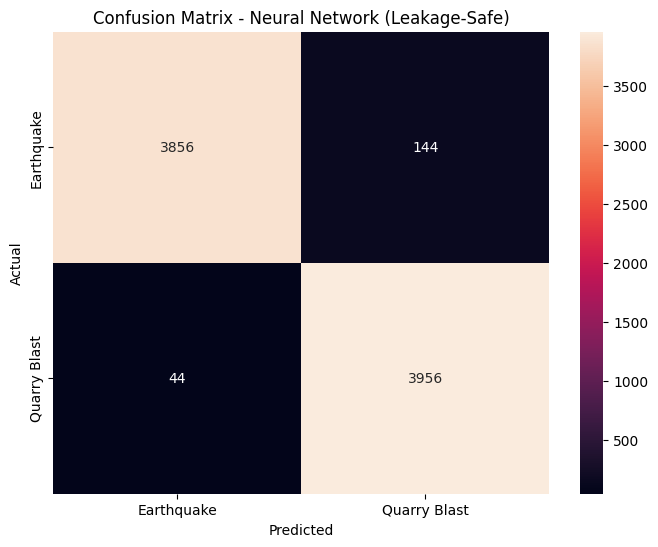

In [15]:
#-------Cell 14---------#
test_loss, test_acc_nn = model.evaluate(X_test, y_test_cat)
print(f"Neural Network Test Accuracy: {test_acc_nn:.4f}")

y_pred_probs = model.predict(X_test)
y_pred_nn = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report (Neural Network, physical features only):")
print(classification_report(y_test, y_pred_nn, target_names=label_encoder.classes_))

cf_matrix = confusion_matrix(y_test, y_pred_nn)
plt.figure(figsize=(8, 6))
sns.heatmap(cf_matrix, annot=True, fmt="d",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Neural Network (Leakage-Safe)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

            Feature  Importance
2             depth    0.445590
9        depthError    0.233115
1         longitude    0.120375
0          latitude    0.079016
3               mag    0.041283
7               rms    0.020614
6              dmin    0.019661
8   horizontalError    0.009725
10         magError    0.009320
11           magNst    0.009131
4               nst    0.006411
5               gap    0.005758


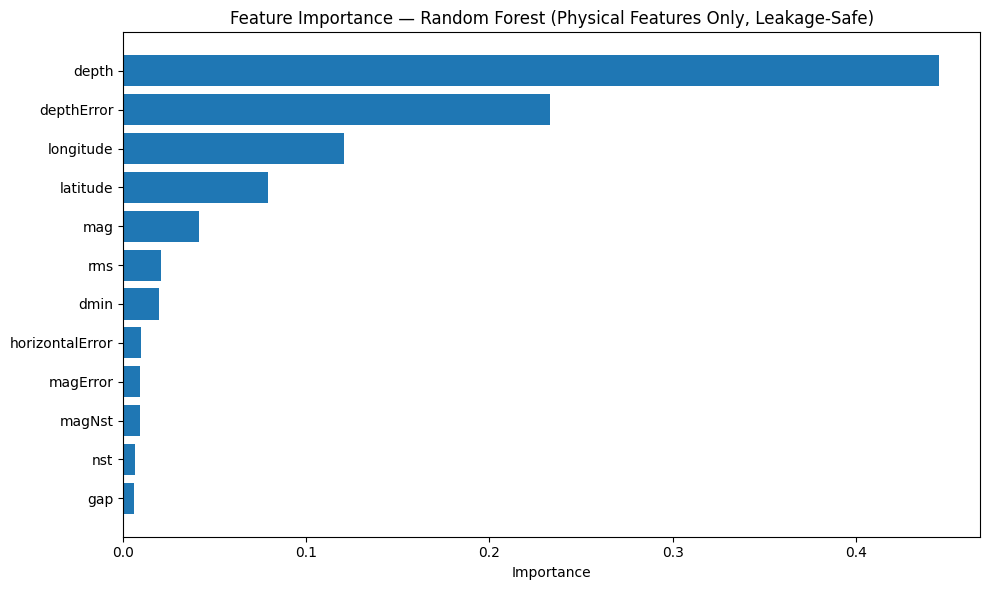

In [16]:
#-------Cell 15---------#
feature_names = X_raw.columns.tolist()
importances = rf_physical.feature_importances_

feat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(feat_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(feat_importance_df['Feature'], feat_importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance — Random Forest (Physical Features Only, Leakage-Safe)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [17]:
#-------Cell 16---------#
print("depthError statistics by event type:\n")
print(df_physical.groupby('Type')['depthError'].describe())

print("\nMost common depthError values per type:")
print("\nQuarry Blast top values:")
print(df_physical[df_physical['Type'] == 'Quarry Blast']['depthError'].value_counts().head(10))
print("\nEarthquake top values:")
print(df_physical[df_physical['Type'] == 'Earthquake']['depthError'].value_counts().head(10))

depthError statistics by event type:

                count       mean         std   min    25%    50%    75%  \
Type                                                                      
Earthquake    17938.0   5.082745  215.360755  0.00   0.39   0.74   2.00   
Quarry Blast  20000.0  25.758051   11.977396  0.12  31.61  31.61  31.61   

                  max  
Type                   
Earthquake    28652.5  
Quarry Blast    236.1  

Most common depthError values per type:

Quarry Blast top values:
depthError
31.61    15987
0.60       319
0.50       315
0.70       220
0.40       216
0.80       170
0.90       105
0.30        81
1.00        78
1.10        40
Name: count, dtype: int64

Earthquake top values:
depthError
0.2    920
0.3    884
0.4    766
0.1    648
0.5    597
0.0    566
0.6    504
0.7    371
0.8    285
0.9    243
Name: count, dtype: int64


In [18]:
#-------Cell 17---------#
physical_cols_clean = [c for c in physical_cols if c != 'depthError']

X_raw_clean = df_physical[physical_cols_clean]

X_train_raw_clean, X_test_raw_clean, y_train_c, y_test_c = train_test_split(
    X_raw_clean, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

train_medians_clean = X_train_raw_clean.median(numeric_only=True)
X_train_imp_clean = X_train_raw_clean.fillna(train_medians_clean)
X_test_imp_clean = X_test_raw_clean.fillna(train_medians_clean)

scaler_clean = StandardScaler()
X_train_clean = scaler_clean.fit_transform(X_train_imp_clean).astype(np.float32)
X_test_clean = scaler_clean.transform(X_test_imp_clean).astype(np.float32)

rf_clean = RandomForestClassifier(
    n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1
)
rf_clean.fit(X_train_clean, y_train_c)
rf_pred_clean = rf_clean.predict(X_test_clean)

print(f"Accuracy without depthError: {accuracy_score(y_test_c, rf_pred_clean):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_c, rf_pred_clean, target_names=label_encoder.classes_))

Accuracy without depthError: 0.9928

Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.99      0.99      0.99      4000
Quarry Blast       0.99      0.99      0.99      4000

    accuracy                           0.99      8000
   macro avg       0.99      0.99      0.99      8000
weighted avg       0.99      0.99      0.99      8000



            Feature  Importance
2             depth    0.594241
1         longitude    0.130514
0          latitude    0.097197
3               mag    0.062669
7               rms    0.029702
6              dmin    0.025519
8   horizontalError    0.017026
9          magError    0.014683
10           magNst    0.014015
5               gap    0.007590
4               nst    0.006843


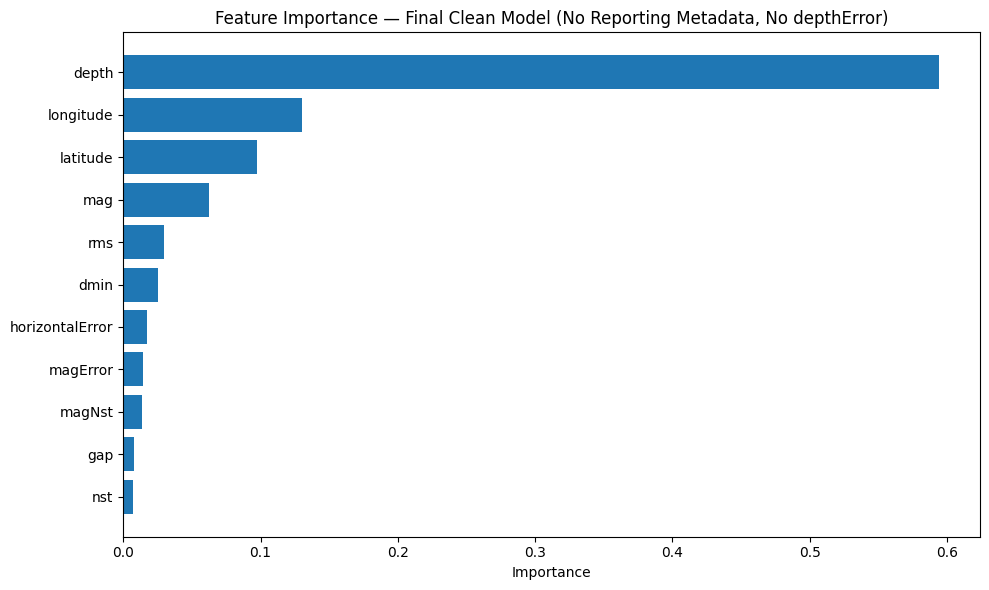

In [19]:
#-------Cell 18---------#
feat_importance_clean = pd.DataFrame({
    'Feature': physical_cols_clean,
    'Importance': rf_clean.feature_importances_
}).sort_values('Importance', ascending=False)

print(feat_importance_clean)

plt.figure(figsize=(10, 6))
plt.barh(feat_importance_clean['Feature'], feat_importance_clean['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance — Final Clean Model (No Reporting Metadata, No depthError)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
#-------Cell 19---------#
y_train_cat_clean = to_categorical(y_train_c, num_classes=2)
y_test_cat_clean = to_categorical(y_test_c, num_classes=2)

model_clean = Sequential()
model_clean.add(Input(shape=(X_train_clean.shape[1],)))
model_clean.add(Dense(32, activation='relu'))
model_clean.add(Dense(64, activation='relu'))
model_clean.add(Dense(2, activation='softmax'))

model_clean.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

monitor_clean = EarlyStopping(monitor='val_loss', patience=5, verbose=1,
                               mode='min', restore_best_weights=True)
reduceLR_clean = ReduceLROnPlateau()

class_weights_clean = compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train_c), y=y_train_c
)
class_weight_dict_clean = dict(enumerate(class_weights_clean))

history_clean = model_clean.fit(
    X_train_clean, y_train_cat_clean,
    validation_split=0.2,
    batch_size=32,
    epochs=50,
    callbacks=[monitor_clean, reduceLR_clean],
    class_weight=class_weight_dict_clean,
    verbose=1
)

Epoch 1/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8997 - loss: 0.2624 - val_accuracy: 0.9463 - val_loss: 0.1508 - learning_rate: 0.0010
Epoch 2/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9532 - loss: 0.1347 - val_accuracy: 0.9528 - val_loss: 0.1301 - learning_rate: 0.0010
Epoch 3/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9584 - loss: 0.1196 - val_accuracy: 0.9630 - val_loss: 0.1145 - learning_rate: 0.0010
Epoch 4/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9594 - loss: 0.1154 - val_accuracy: 0.9594 - val_loss: 0.1160 - learning_rate: 0.0010
Epoch 5/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9613 - loss: 0.1105 - val_accuracy: 0.9588 - val_loss: 0.1160 - learning_rate: 0.0010
Epoch 6/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9630 - loss: 0.1067 - val_accuracy: 0.9648 - val_loss: 0.1077 - learning_rate: 0.0010
Epoch 7/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9649 - loss: 0.1028 - 

In [21]:
#-------Cell 20---------#
test_loss_c, test_acc_nn_clean = model_clean.evaluate(X_test_clean, y_test_cat_clean)
print(f"Neural Network Test Accuracy (final clean): {test_acc_nn_clean:.4f}")

y_pred_probs_clean = model_clean.predict(X_test_clean)
y_pred_nn_clean = np.argmax(y_pred_probs_clean, axis=1)

print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_nn_clean, target_names=label_encoder.classes_))

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9778 - loss: 0.0686
Neural Network Test Accuracy (final clean): 0.9778
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.98      0.98      0.98      4000
Quarry Blast       0.98      0.98      0.98      4000

    accuracy                           0.98      8000
   macro avg       0.98      0.98      0.98      8000
weighted avg       0.98      0.98      0.98      8000



In [22]:
#-------Cell 21---------#
!pip install shap --quiet

import shap

explainer = shap.TreeExplainer(rf_clean)

# SHAP on a sample of the test set (faster than the full 8000 rows)
sample_idx = np.random.choice(X_test_clean.shape[0], 500, replace=False)
X_sample = X_test_clean[sample_idx]

shap_values = explainer.shap_values(X_sample)

print("SHAP values computed. Shape:", np.array(shap_values).shape)

SHAP values computed. Shape: (500, 11, 2)


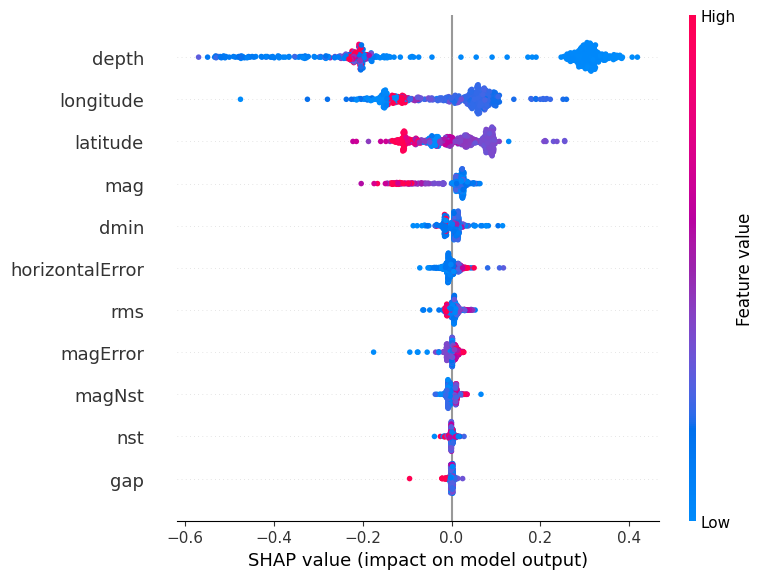

In [23]:
#-------Cell 22---------#
shap.summary_plot(
    shap_values[:, :, 1],  # SHAP values for class 1 (Quarry Blast)
    X_sample,
    feature_names=physical_cols_clean,
    show=True
)

In [24]:
#-------Cell 23---------#
import random

# Fix ALL sources of randomness for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# Split ONCE on row indices, before touching any specific feature columns.
# Every experiment below reuses these exact same rows for train/test,
# guaranteed by construction rather than by matching random_state values.
all_indices = df.index.values
y_all = label_encoder.transform(df['Type'])

train_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=SEED,
    stratify=y_all
)

print("Train rows:", len(train_idx))
print("Test rows :", len(test_idx))
print("\nTrain class balance:", pd.Series(y_all[train_idx]).value_counts().to_dict())
print("Test class balance :", pd.Series(y_all[test_idx]).value_counts().to_dict())

Train rows: 32000
Test rows : 8000

Train class balance: {0: 16000, 1: 16000}
Test class balance : {1: 4000, 0: 4000}


In [25]:
#-------Cell 24---------#
#-----Reusable experiment function-----#

def run_experiment(feature_cols, experiment_name,
                   train_idx=train_idx, test_idx=test_idx):

    print(f"\n{'='*60}")
    print(experiment_name)
    print(f"{'='*60}")

    # Select features and target
    data = df[feature_cols + ['Type']].copy()

    X = data[feature_cols]

    # Create labels with explicit DataFrame-index alignment
    y_series = pd.Series(
        label_encoder.transform(df['Type']),
        index=df.index
    )

    # Split using the fixed indices from Cell 23
    X_train = X.loc[train_idx].copy()
    X_test = X.loc[test_idx].copy()

    y_train = y_series.loc[train_idx].values
    y_test = y_series.loc[test_idx].values

    # Identify numeric and categorical features
    categorical_cols = X_train.select_dtypes(
        include=['object', 'category']
    ).columns.tolist()

    numeric_cols = [
        col for col in feature_cols
        if col not in categorical_cols
    ]

    # --------------------------------------------------
    # Missing-value imputation
    # Fit only on training data
    # --------------------------------------------------

    X_train_processed = X_train.copy()
    X_test_processed = X_test.copy()

    # Numeric columns: median imputation
    for col in numeric_cols:
        median_value = X_train_processed[col].median()

        X_train_processed[col] = (
            X_train_processed[col].fillna(median_value)
        )

        X_test_processed[col] = (
            X_test_processed[col].fillna(median_value)
        )

    # Categorical columns: mode imputation
    for col in categorical_cols:
        mode_value = X_train_processed[col].mode()

        if len(mode_value) > 0:
            mode_value = mode_value.iloc[0]
        else:
            mode_value = 'Unknown'

        X_train_processed[col] = (
            X_train_processed[col].fillna(mode_value)
        )

        X_test_processed[col] = (
            X_test_processed[col].fillna(mode_value)
        )

    # --------------------------------------------------
    # One-hot encode categorical features
    # --------------------------------------------------

    X_train_processed = pd.get_dummies(
        X_train_processed,
        columns=categorical_cols,
        drop_first=False
    )

    X_test_processed = pd.get_dummies(
        X_test_processed,
        columns=categorical_cols,
        drop_first=False
    )

    # Make sure test columns exactly match training columns
    X_test_processed = X_test_processed.reindex(
        columns=X_train_processed.columns,
        fill_value=0
    )

    # --------------------------------------------------
    # Scale numeric features
    # Fit scaler only on training data
    # --------------------------------------------------

    scaler = StandardScaler()

    numeric_cols_after_encoding = [
        col for col in numeric_cols
        if col in X_train_processed.columns
    ]

    X_train_processed[numeric_cols_after_encoding] = (
        scaler.fit_transform(
            X_train_processed[numeric_cols_after_encoding]
        )
    )

    X_test_processed[numeric_cols_after_encoding] = (
        scaler.transform(
            X_test_processed[numeric_cols_after_encoding]
        )
    )

    # Convert to NumPy arrays
    X_train_final = X_train_processed.values.astype(np.float32)
    X_test_final = X_test_processed.values.astype(np.float32)

    feature_names_final = X_train_processed.columns.tolist()

    # --------------------------------------------------
    # Random Forest
    # --------------------------------------------------

    rf_model = RandomForestClassifier(
        n_estimators=200,
        random_state=SEED,
        class_weight='balanced',
        n_jobs=-1
    )

    rf_model.fit(X_train_final, y_train)

    rf_preds = rf_model.predict(X_test_final)

    rf_accuracy = accuracy_score(y_test, rf_preds)

    print(f"\nRandom Forest Accuracy: {rf_accuracy:.4f}")
    print("\nRandom Forest Classification Report:")
    print(
        classification_report(
            y_test,
            rf_preds,
            target_names=label_encoder.classes_
        )
    )

    # --------------------------------------------------
    # Neural Network
    # --------------------------------------------------

    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    nn_model = Sequential([
        Input(shape=(X_train_final.shape[1],)),
        Dense(32, activation='relu'),
        Dense(64, activation='relu'),
        Dense(2, activation='softmax')
    ])

    nn_model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Class weights
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )

    class_weight_dict = dict(
        enumerate(class_weights)
    )

    # Early stopping
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=0
    )

    # Train NN
    nn_model.fit(
        X_train_final,
        y_train,
        validation_split=0.2,
        batch_size=32,
        epochs=50,
        callbacks=[early_stopping],
        class_weight=class_weight_dict,
        verbose=0
    )

    # Evaluate NN
    _, nn_accuracy = nn_model.evaluate(
        X_test_final,
        y_test,
        verbose=0
    )

    nn_preds = np.argmax(
        nn_model.predict(X_test_final, verbose=0),
        axis=1
    )

    print(f"\nNeural Network Accuracy: {nn_accuracy:.4f}")
    print("\nNeural Network Classification Report:")
    print(
        classification_report(
            y_test,
            nn_preds,
            target_names=label_encoder.classes_
        )
    )

    # --------------------------------------------------
    # Return all useful results
    # --------------------------------------------------

    return {
        'experiment_name': experiment_name,
        'feature_cols': feature_cols,
        'feature_names_final': feature_names_final,

        'rf_model': rf_model,
        'nn_model': nn_model,

        'X_train': X_train_final,
        'X_test': X_test_final,

        'y_train': y_train,
        'y_test': y_test,

        'rf_preds': rf_preds,
        'nn_preds': nn_preds,

        'rf_accuracy': rf_accuracy,
        'nn_accuracy': nn_accuracy,

        'scaler': scaler
    }

In [26]:
#-------Cell 25---------#
physical_only = [
    'latitude', 'longitude', 'depth', 'mag',
    'nst', 'gap', 'dmin', 'rms',
    'horizontalError', 'depthError', 'magError', 'magNst'
]

physical_plus_metadata = physical_only + ['net', 'status', 'locationSource', 'magSource']

physical_plus_metadata_no_deptherror = [c for c in physical_plus_metadata if c != 'depthError']

results = []
results.append(run_experiment(physical_only, "A: Physical only"))
results.append(run_experiment(physical_plus_metadata, "B: Physical + reporting metadata"))
results.append(run_experiment(physical_plus_metadata_no_deptherror, "C: Physical + metadata, no depthError"))


A: Physical only

Random Forest Accuracy: 0.9935

Random Forest Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.99      0.99      0.99      4000
Quarry Blast       0.99      0.99      0.99      4000

    accuracy                           0.99      8000
   macro avg       0.99      0.99      0.99      8000
weighted avg       0.99      0.99      0.99      8000


Neural Network Accuracy: 0.9809

Neural Network Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.99      0.98      0.98      4000
Quarry Blast       0.98      0.99      0.98      4000

    accuracy                           0.98      8000
   macro avg       0.98      0.98      0.98      8000
weighted avg       0.98      0.98      0.98      8000


B: Physical + reporting metadata

Random Forest Accuracy: 0.9946

Random Forest Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.99    

In [27]:
#-------Cell 26---------#
# 1. Exact duplicate rows (identical across all columns)
exact_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {exact_dupes}")

# 2. Duplicate event IDs (USGS assigns a unique 'id' to every event --
#    if the same id appears twice, we accidentally pulled the same event twice)
id_dupes = df['id'].duplicated().sum()
print(f"Duplicate USGS event IDs: {id_dupes}")

# 3. Near-duplicate events: same time + very close location, possibly
#    the same physical event pulled under both queries (unlikely across
#    types, but worth checking) or duplicated within the same type
#    across overlapping yearly queries.
df['time_rounded'] = pd.to_datetime(df['time']).dt.floor('min')
near_dupes = df.duplicated(subset=['time_rounded', 'latitude', 'longitude', 'Type']).sum()
print(f"Near-duplicate events (same minute, coords, and type): {near_dupes}")

# Show a few examples if any exist
if id_dupes > 0:
    print("\nExample duplicate IDs:")
    print(df[df['id'].duplicated(keep=False)].sort_values('id')[['id', 'time', 'Type']].head(10))

Exact duplicate rows: 0
Duplicate USGS event IDs: 0
Near-duplicate events (same minute, coords, and type): 0


In [28]:
#-------Cell 27---------#
from sklearn.model_selection import StratifiedKFold

physical_only_df = df[physical_only + ['Type']].copy()
X_cv = physical_only_df.drop('Type', axis=1)
y_cv = label_encoder.transform(physical_only_df['Type'])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rf_cv_scores = []

for fold, (train_i, test_i) in enumerate(skf.split(X_cv, y_cv), 1):
    X_tr, X_te = X_cv.iloc[train_i].copy(), X_cv.iloc[test_i].copy()
    y_tr, y_te = y_cv[train_i], y_cv[test_i]

    medians = X_tr.median()
    X_tr = X_tr.fillna(medians)
    X_te = X_te.fillna(medians)

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr).astype(np.float32)
    X_te_s = sc.transform(X_te).astype(np.float32)

    rf_fold = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                      random_state=SEED, n_jobs=-1)
    rf_fold.fit(X_tr_s, y_tr)
    fold_acc = accuracy_score(y_te, rf_fold.predict(X_te_s))
    rf_cv_scores.append(fold_acc)
    print(f"Fold {fold}: {fold_acc:.4f}")

rf_cv_scores = np.array(rf_cv_scores)
print(f"\nMean accuracy: {rf_cv_scores.mean():.4f}")
print(f"Std deviation: {rf_cv_scores.std():.4f}")

Fold 1: 0.9918
Fold 2: 0.9944
Fold 3: 0.9950
Fold 4: 0.9941
Fold 5: 0.9925

Mean accuracy: 0.9935
Std deviation: 0.0012


In [29]:
#-------Cell 28---------#
df['event_year'] = pd.to_datetime(df['time']).dt.year

train_years_mask = df['event_year'] <= 2019
test_years_mask = df['event_year'] >= 2020

print("Training period (2000-2019) class balance:")
print(df[train_years_mask]['Type'].value_counts())
print("\nTest period (2020-2024) class balance:")
print(df[test_years_mask]['Type'].value_counts())

Training period (2000-2019) class balance:
Type
Earthquake      16000
Quarry Blast    13742
Name: count, dtype: int64

Test period (2020-2024) class balance:
Type
Quarry Blast    6258
Earthquake      4000
Name: count, dtype: int64


In [30]:
#-------Cell 29---------#
train_temporal = df[train_years_mask].copy()
test_temporal = df[test_years_mask].copy()

X_train_temp = train_temporal[physical_only].copy()
X_test_temp = test_temporal[physical_only].copy()
y_train_temp = label_encoder.transform(train_temporal['Type'])
y_test_temp = label_encoder.transform(test_temporal['Type'])

# Impute using TRAIN (past) medians only
medians_temp = X_train_temp.median()
X_train_temp = X_train_temp.fillna(medians_temp)
X_test_temp = X_test_temp.fillna(medians_temp)

# Scale using TRAIN (past) stats only
scaler_temp = StandardScaler()
X_train_temp_s = scaler_temp.fit_transform(X_train_temp).astype(np.float32)
X_test_temp_s = scaler_temp.transform(X_test_temp).astype(np.float32)

rf_temporal = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                      random_state=SEED, n_jobs=-1)
rf_temporal.fit(X_train_temp_s, y_train_temp)
rf_temp_pred = rf_temporal.predict(X_test_temp_s)

print("=" * 60)
print("TEMPORAL SPLIT: Trained on 2000-2019, Tested on 2020-2024")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test_temp, rf_temp_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_temp, rf_temp_pred, target_names=label_encoder.classes_))

TEMPORAL SPLIT: Trained on 2000-2019, Tested on 2020-2024
Accuracy: 0.9906

Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.98      1.00      0.99      4000
Quarry Blast       1.00      0.99      0.99      6258

    accuracy                           0.99     10258
   macro avg       0.99      0.99      0.99     10258
weighted avg       0.99      0.99      0.99     10258



In [31]:
#-------Cell 30---------#
nn_cv_scores = []

for fold, (train_i, test_i) in enumerate(skf.split(X_cv, y_cv), 1):
    X_tr, X_te = X_cv.iloc[train_i].copy(), X_cv.iloc[test_i].copy()
    y_tr, y_te = y_cv[train_i], y_cv[test_i]

    medians = X_tr.median()
    X_tr = X_tr.fillna(medians)
    X_te = X_te.fillna(medians)

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr).astype(np.float32)
    X_te_s = sc.transform(X_te).astype(np.float32)

    y_tr_cat = to_categorical(y_tr, num_classes=2)
    y_te_cat = to_categorical(y_te, num_classes=2)

    tf.random.set_seed(SEED)
    nn_fold = Sequential()
    nn_fold.add(Input(shape=(X_tr_s.shape[1],)))
    nn_fold.add(Dense(32, activation='relu'))
    nn_fold.add(Dense(64, activation='relu'))
    nn_fold.add(Dense(2, activation='softmax'))
    nn_fold.compile(optimizer=Adam(learning_rate=0.001),
                     loss='categorical_crossentropy', metrics=['accuracy'])

    cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
    cw_dict = dict(enumerate(cw))
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)

    nn_fold.fit(X_tr_s, y_tr_cat, validation_split=0.2, batch_size=32,
                epochs=50, callbacks=[es], class_weight=cw_dict, verbose=0)

    _, fold_acc = nn_fold.evaluate(X_te_s, y_te_cat, verbose=0)
    nn_cv_scores.append(fold_acc)
    print(f"Fold {fold}: {fold_acc:.4f}")

nn_cv_scores = np.array(nn_cv_scores)
print(f"\nMean accuracy: {nn_cv_scores.mean():.4f}")
print(f"Std deviation: {nn_cv_scores.std():.4f}")

Fold 1: 0.9714
Fold 2: 0.9761
Fold 3: 0.9747
Fold 4: 0.9711
Fold 5: 0.9712

Mean accuracy: 0.9729
Std deviation: 0.0021


In [32]:
#-------Cell 31---------#
y_train_temp_cat = to_categorical(y_train_temp, num_classes=2)
y_test_temp_cat = to_categorical(y_test_temp, num_classes=2)

tf.random.set_seed(SEED)
nn_temporal = Sequential()
nn_temporal.add(Input(shape=(X_train_temp_s.shape[1],)))
nn_temporal.add(Dense(32, activation='relu'))
nn_temporal.add(Dense(64, activation='relu'))
nn_temporal.add(Dense(2, activation='softmax'))
nn_temporal.compile(optimizer=Adam(learning_rate=0.001),
                     loss='categorical_crossentropy', metrics=['accuracy'])

cw_temp = compute_class_weight('balanced', classes=np.unique(y_train_temp), y=y_train_temp)
cw_temp_dict = dict(enumerate(cw_temp))
es_temp = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)

nn_temporal.fit(X_train_temp_s, y_train_temp_cat, validation_split=0.2, batch_size=32,
                epochs=50, callbacks=[es_temp], class_weight=cw_temp_dict, verbose=1)

_, nn_temp_acc = nn_temporal.evaluate(X_test_temp_s, y_test_temp_cat, verbose=0)
print(f"\nNeural Network Temporal Accuracy (train 2000-2019, test 2020-2024): {nn_temp_acc:.4f}")

Epoch 1/50
744/744 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9001 - loss: 0.2368 - val_accuracy: 0.9565 - val_loss: 0.1128
Epoch 2/50
744/744 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9623 - loss: 0.1204 - val_accuracy: 0.9667 - val_loss: 0.0924
Epoch 3/50
744/744 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9655 - loss: 0.0987 - val_accuracy: 0.9692 - val_loss: 0.0860
Epoch 4/50
744/744 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9686 - loss: 0.0852 - val_accuracy: 0.9696 - val_loss: 0.0836
Epoch 5/50
744/744 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9704 - loss: 0.0810 - val_accuracy: 0.9684 - val_loss: 0.0841
Epoch 6/50
744/744 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9715 - loss: 0.0782 - val_accuracy: 0.9684 - val_loss: 0.0845
Epoch 7/50
744/744 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9731 - loss: 0.0755 - val_accuracy: 0.9689 - val_loss: 0.0819
Epoch 8/50
744/744 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9736 - loss: 0.0737 - val_accuracy: 0.

In [33]:
#-------Cell 32---------#
#-----McNemar's test----#
from statsmodels.stats.contingency_tables import mcnemar

# Reuse the original Experiment A predictions (physical-only, main split)
result_A = results[0]  # "A: Physical only" from Cell 25
rf_A = result_A['rf_model']
nn_A = result_A['nn_model']
X_test_A = result_A['X_test']
y_test_A = result_A['y_test']

rf_preds_A = rf_A.predict(X_test_A)
nn_preds_A = np.argmax(nn_A.predict(X_test_A, verbose=0), axis=1)

rf_correct = (rf_preds_A == y_test_A)
nn_correct = (nn_preds_A == y_test_A)

both_correct = np.sum(rf_correct & nn_correct)
rf_only = np.sum(rf_correct & ~nn_correct)
nn_only = np.sum(~rf_correct & nn_correct)
both_wrong = np.sum(~rf_correct & ~nn_correct)

table = [[both_correct, rf_only], [nn_only, both_wrong]]
print("Contingency table [[both right, RF only right], [NN only right, both wrong]]:")
print(table)

result = mcnemar(table, exact=False, correction=True)
print(f"\nMcNemar's test statistic: {result.statistic:.4f}")
print(f"p-value: {result.pvalue:.6f}")

Contingency table [[both right, RF only right], [NN only right, both wrong]]:
[[np.int64(7831), np.int64(117)], [np.int64(16), np.int64(36)]]

McNemar's test statistic: 75.1880
p-value: 0.000000


In [34]:
#-------Cell 33---------#
#-----Depth-only Random Forest-----#

depth_only = ['depth']

depth_result = run_experiment(
    depth_only,
    "D: Depth only"
)

print("\nDepth-only experiment completed.")


D: Depth only

Random Forest Accuracy: 0.9580

Random Forest Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.97      0.95      0.96      4000
Quarry Blast       0.95      0.97      0.96      4000

    accuracy                           0.96      8000
   macro avg       0.96      0.96      0.96      8000
weighted avg       0.96      0.96      0.96      8000


Neural Network Accuracy: 0.9551

Neural Network Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.97      0.94      0.95      4000
Quarry Blast       0.94      0.97      0.96      4000

    accuracy                           0.96      8000
   macro avg       0.96      0.96      0.96      8000
weighted avg       0.96      0.96      0.96      8000


Depth-only experiment completed.


In [35]:
#-------Cell 34---------#
#-----Physical features without depth-----#

physical_no_depth = [
    'latitude',
    'longitude',
    'mag',
    'nst',
    'gap',
    'dmin',
    'rms',
    'horizontalError',
    'depthError',
    'magError',
    'magNst'
]

no_depth_result = run_experiment(
    physical_no_depth,
    "E: Physical features without depth"
)

print("\nNo-depth experiment completed.")


E: Physical features without depth

Random Forest Accuracy: 0.9889

Random Forest Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.99      0.99      0.99      4000
Quarry Blast       0.99      0.99      0.99      4000

    accuracy                           0.99      8000
   macro avg       0.99      0.99      0.99      8000
weighted avg       0.99      0.99      0.99      8000


Neural Network Accuracy: 0.9628

Neural Network Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.96      0.96      0.96      4000
Quarry Blast       0.96      0.96      0.96      4000

    accuracy                           0.96      8000
   macro avg       0.96      0.96      0.96      8000
weighted avg       0.96      0.96      0.96      8000


No-depth experiment completed.


In [36]:
# ============================================================
# Cell 35 — Geographic Holdout Split
# Final clean 11-feature model (without depthError)
# ============================================================

from sklearn.model_selection import GroupShuffleSplit

# Use the final clean feature set
geo_features = physical_cols_clean.copy()

# ------------------------------------------------------------
# Create geographic dataframe
# ------------------------------------------------------------
# latitude and longitude are already included in geo_features,
# so we do NOT add them a second time.

geo_df = df[geo_features + ['Type']].copy()

# ------------------------------------------------------------
# Create geographic grid cells
# ------------------------------------------------------------
# Events in the same geographic grid cell belong to the same
# geographic group.
#
# Entire geographic groups are kept together, so the same
# geographic area cannot appear in both train and test.

GRID_SIZE = 5.0  # degrees

geo_df['lat_grid'] = np.floor(
    geo_df['latitude'] / GRID_SIZE
)

geo_df['lon_grid'] = np.floor(
    geo_df['longitude'] / GRID_SIZE
)

geo_df['geo_group'] = (
    geo_df['lat_grid'].astype(str)
    + "_"
    + geo_df['lon_grid'].astype(str)
)

# ------------------------------------------------------------
# Create geographic holdout split
# ------------------------------------------------------------

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=SEED
)

train_pos, test_pos = next(
    gss.split(
        geo_df,
        y=geo_df['Type'],
        groups=geo_df['geo_group']
    )
)

geo_train = geo_df.iloc[train_pos].copy()
geo_test = geo_df.iloc[test_pos].copy()

print("=" * 60)
print("GEOGRAPHIC HOLDOUT SPLIT")
print("=" * 60)

print("\nTotal events:", len(geo_df))
print("Training events:", len(geo_train))
print("Testing events :", len(geo_test))

print("\nTraining class distribution:")
print(geo_train['Type'].value_counts())

print("\nTesting class distribution:")
print(geo_test['Type'].value_counts())

print("\nNumber of geographic groups:")
print("Training groups:", geo_train['geo_group'].nunique())
print("Testing groups :", geo_test['geo_group'].nunique())

# ------------------------------------------------------------
# Verify that NO geographic group appears in both sets
# ------------------------------------------------------------

train_groups = set(geo_train['geo_group'])
test_groups = set(geo_test['geo_group'])

overlap = train_groups.intersection(test_groups)

print("\nGeographic group overlap:", len(overlap))

if len(overlap) == 0:
    print("PASS: No geographic groups are shared between train and test.")
else:
    print("WARNING: Geographic leakage detected!")

# ------------------------------------------------------------
# Prepare X and y
# ------------------------------------------------------------

X_train_geo = geo_train[geo_features].copy()
X_test_geo = geo_test[geo_features].copy()

y_train_geo = label_encoder.transform(
    geo_train['Type']
)

y_test_geo = label_encoder.transform(
    geo_test['Type']
)

print("\nX_train shape:", X_train_geo.shape)
print("X_test shape :", X_test_geo.shape)

GEOGRAPHIC HOLDOUT SPLIT

Total events: 40000
Training events: 31165
Testing events : 8835

Training class distribution:
Type
Earthquake      16174
Quarry Blast    14991
Name: count, dtype: int64

Testing class distribution:
Type
Quarry Blast    5009
Earthquake      3826
Name: count, dtype: int64

Number of geographic groups:
Training groups: 336
Testing groups : 85

Geographic group overlap: 0
PASS: No geographic groups are shared between train and test.

X_train shape: (31165, 11)
X_test shape : (8835, 11)


In [37]:
# ============================================================
# Cell 36 — Geographic Holdout Random Forest
# Final clean 11-feature model
# ============================================================

# ------------------------------------------------------------
# Missing-value imputation
# IMPORTANT:
# Medians are calculated ONLY from geographic training data.
# ------------------------------------------------------------

geo_train_medians = X_train_geo.median(numeric_only=True)

X_train_geo_imp = X_train_geo.fillna(geo_train_medians)
X_test_geo_imp = X_test_geo.fillna(geo_train_medians)

print("Remaining missing values in geographic training set:",
      X_train_geo_imp.isnull().sum().sum())

print("Remaining missing values in geographic test set:",
      X_test_geo_imp.isnull().sum().sum())

# ------------------------------------------------------------
# Scaling
# IMPORTANT:
# Scaler is fitted ONLY on geographic training data.
# ------------------------------------------------------------

scaler_geo = StandardScaler()

X_train_geo_scaled = scaler_geo.fit_transform(
    X_train_geo_imp
).astype(np.float32)

X_test_geo_scaled = scaler_geo.transform(
    X_test_geo_imp
).astype(np.float32)

print("\nScaled training shape:", X_train_geo_scaled.shape)
print("Scaled testing shape :", X_test_geo_scaled.shape)

# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

rf_geo = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)

rf_geo.fit(
    X_train_geo_scaled,
    y_train_geo
)

# Predictions
rf_geo_pred = rf_geo.predict(
    X_test_geo_scaled
)

rf_geo_prob = rf_geo.predict_proba(
    X_test_geo_scaled
)[:, 1]

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("GEOGRAPHIC HOLDOUT — RANDOM FOREST")
print("=" * 60)

print(
    f"Accuracy : "
    f"{accuracy_score(y_test_geo, rf_geo_pred):.4f}"
)

print(
    f"Precision: "
    f"{precision_score(y_test_geo, rf_geo_pred):.4f}"
)

print(
    f"Recall   : "
    f"{recall_score(y_test_geo, rf_geo_pred):.4f}"
)

print(
    f"F1-score : "
    f"{f1_score(y_test_geo, rf_geo_pred):.4f}"
)

print(
    f"ROC-AUC  : "
    f"{roc_auc_score(y_test_geo, rf_geo_prob):.4f}"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test_geo,
        rf_geo_pred,
        target_names=label_encoder.classes_
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test_geo,
        rf_geo_pred
    )
)

Remaining missing values in geographic training set: 0
Remaining missing values in geographic test set: 0

Scaled training shape: (31165, 11)
Scaled testing shape : (8835, 11)

GEOGRAPHIC HOLDOUT — RANDOM FOREST
Accuracy : 0.6448
Precision: 0.9629
Recall   : 0.3885
F1-score : 0.5536
ROC-AUC  : 0.9634

Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.55      0.98      0.71      3826
Quarry Blast       0.96      0.39      0.55      5009

    accuracy                           0.64      8835
   macro avg       0.76      0.68      0.63      8835
weighted avg       0.78      0.64      0.62      8835


Confusion Matrix:
[[3751   75]
 [3063 1946]]


GEOGRAPHIC RANDOM FOREST — THRESHOLD ANALYSIS
ROC-AUC: 0.9634
Best Youden threshold: 0.1950
TPR at best threshold: 0.9499
FPR at best threshold: 0.0523

PERFORMANCE AT BEST ROC THRESHOLD
Accuracy : 0.9490
Precision: 0.9597
Recall   : 0.9499
F1-score : 0.9548

Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.94      0.95      0.94      3826
Quarry Blast       0.96      0.95      0.95      5009

    accuracy                           0.95      8835
   macro avg       0.95      0.95      0.95      8835
weighted avg       0.95      0.95      0.95      8835


Confusion Matrix:
[[3626  200]
 [ 251 4758]]


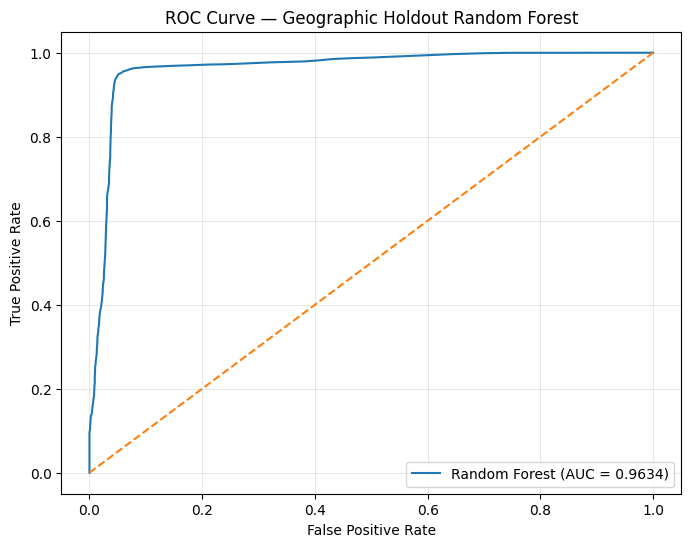

In [38]:
# ============================================================
# Cell 37 — Geographic RF Probability Analysis
# ============================================================

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    auc
)

# ------------------------------------------------------------
# ROC curve
# ------------------------------------------------------------

fpr_geo, tpr_geo, thresholds_geo = roc_curve(
    y_test_geo,
    rf_geo_prob
)

roc_auc_geo = auc(
    fpr_geo,
    tpr_geo
)

# Find threshold with maximum Youden's J statistic
youden_j = tpr_geo - fpr_geo

best_idx = np.argmax(youden_j)

best_threshold_geo = thresholds_geo[best_idx]

print("=" * 60)
print("GEOGRAPHIC RANDOM FOREST — THRESHOLD ANALYSIS")
print("=" * 60)

print(f"ROC-AUC: {roc_auc_geo:.4f}")

print(
    f"Best Youden threshold: "
    f"{best_threshold_geo:.4f}"
)

print(
    f"TPR at best threshold: "
    f"{tpr_geo[best_idx]:.4f}"
)

print(
    f"FPR at best threshold: "
    f"{fpr_geo[best_idx]:.4f}"
)

# ------------------------------------------------------------
# Evaluate at the new threshold
# ------------------------------------------------------------

rf_geo_pred_best = (
    rf_geo_prob >= best_threshold_geo
).astype(int)

print("\n" + "=" * 60)
print("PERFORMANCE AT BEST ROC THRESHOLD")
print("=" * 60)

print(
    f"Accuracy : "
    f"{accuracy_score(y_test_geo, rf_geo_pred_best):.4f}"
)

print(
    f"Precision: "
    f"{precision_score(y_test_geo, rf_geo_pred_best):.4f}"
)

print(
    f"Recall   : "
    f"{recall_score(y_test_geo, rf_geo_pred_best):.4f}"
)

print(
    f"F1-score : "
    f"{f1_score(y_test_geo, rf_geo_pred_best):.4f}"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test_geo,
        rf_geo_pred_best,
        target_names=label_encoder.classes_
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test_geo,
        rf_geo_pred_best
    )
)

# ------------------------------------------------------------
# Plot ROC curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_geo,
    tpr_geo,
    label=f'Random Forest (AUC = {roc_auc_geo:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Geographic Holdout Random Forest')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [39]:
# ============================================================
# Cell 38 — Geographic Holdout Neural Network
# Final clean 11-feature model
# ============================================================

# ------------------------------------------------------------
# Convert labels to categorical format
# ------------------------------------------------------------

y_train_geo_cat = to_categorical(
    y_train_geo,
    num_classes=2
)

y_test_geo_cat = to_categorical(
    y_test_geo,
    num_classes=2
)

# ------------------------------------------------------------
# Fix random seeds
# ------------------------------------------------------------

tf.random.set_seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------
# Build Neural Network
# Same architecture as the main experiment
# ------------------------------------------------------------

nn_geo = Sequential([
    Input(shape=(X_train_geo_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(64, activation='relu'),
    Dense(2, activation='softmax')
])

nn_geo.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------------------------------------------------
# Class weights
# Calculated ONLY from geographic training data
# ------------------------------------------------------------

class_weights_geo = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_geo),
    y=y_train_geo
)

class_weight_dict_geo = dict(
    enumerate(class_weights_geo)
)

print("Geographic training class weights:")
print(class_weight_dict_geo)

# ------------------------------------------------------------
# Early stopping
# ------------------------------------------------------------

early_stopping_geo = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ------------------------------------------------------------
# Train Neural Network
# ------------------------------------------------------------

history_geo = nn_geo.fit(
    X_train_geo_scaled,
    y_train_geo_cat,
    validation_split=0.20,
    batch_size=32,
    epochs=50,
    callbacks=[early_stopping_geo],
    class_weight=class_weight_dict_geo,
    verbose=1
)

# ------------------------------------------------------------
# Evaluate on completely unseen geographic test set
# ------------------------------------------------------------

geo_test_loss, geo_test_accuracy = nn_geo.evaluate(
    X_test_geo_scaled,
    y_test_geo_cat,
    verbose=0
)

# Predictions
nn_geo_probs = nn_geo.predict(
    X_test_geo_scaled,
    verbose=0
)

nn_geo_pred = np.argmax(
    nn_geo_probs,
    axis=1
)

# Probability for class 1 = Quarry Blast
nn_geo_prob = nn_geo_probs[:, 1]

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("GEOGRAPHIC HOLDOUT — NEURAL NETWORK")
print("=" * 60)

print(
    f"Accuracy : "
    f"{accuracy_score(y_test_geo, nn_geo_pred):.4f}"
)

print(
    f"Precision: "
    f"{precision_score(y_test_geo, nn_geo_pred):.4f}"
)

print(
    f"Recall   : "
    f"{recall_score(y_test_geo, nn_geo_pred):.4f}"
)

print(
    f"F1-score : "
    f"{f1_score(y_test_geo, nn_geo_pred):.4f}"
)

print(
    f"ROC-AUC  : "
    f"{roc_auc_score(y_test_geo, nn_geo_prob):.4f}"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test_geo,
        nn_geo_pred,
        target_names=label_encoder.classes_
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test_geo,
        nn_geo_pred
    )
)

Geographic training class weights:
{0: np.float64(0.9634289600593545), 1: np.float64(1.039457007537856)}
Epoch 1/50
780/780 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9100 - loss: 0.2307 - val_accuracy: 0.8830 - val_loss: 0.2549
Epoch 2/50
780/780 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9634 - loss: 0.1025 - val_accuracy: 0.9068 - val_loss: 0.2277
Epoch 3/50
780/780 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9663 - loss: 0.0934 - val_accuracy: 0.9159 - val_loss: 0.2094
Epoch 4/50
780/780 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9676 - loss: 0.0876 - val_accuracy: 0.9223 - val_loss: 0.1961
Epoch 5/50
780/780 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9697 - loss: 0.0837 - val_accuracy: 0.9238 - val_loss: 0.1939
Epoch 6/50
780/780 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9702 - loss: 0.0806 - val_accuracy: 0.9268 - val_loss: 0.1860
Epoch 7/50
780/780 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9714 - loss: 0.0773 - val_accuracy: 0.9318 - val_loss: 0.1755

In [40]:
# ============================================================
# Cell 39 — Leakage-Safe RF Threshold Selection
# Threshold is selected using TRAINING data only
# Geographic test set remains completely untouched
# ============================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve

print("=" * 60)
print("LEAKAGE-SAFE RF THRESHOLD SELECTION")
print("=" * 60)

# ------------------------------------------------------------
# 1. Generate out-of-fold predictions on geographic TRAINING data
# ------------------------------------------------------------

X_geo_train = X_train_geo_scaled
y_geo_train = y_train_geo

skf_geo = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

oof_prob_geo = np.zeros(len(y_geo_train))

for fold, (train_fold, val_fold) in enumerate(
    skf_geo.split(X_geo_train, y_geo_train), start=1
):

    rf_fold = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1,
        max_depth=None
    )

    rf_fold.fit(
        X_geo_train[train_fold],
        y_geo_train[train_fold]
    )

    oof_prob_geo[val_fold] = rf_fold.predict_proba(
        X_geo_train[val_fold]
    )[:, 1]

    print(f"Fold {fold} completed.")

# ------------------------------------------------------------
# 2. Check OOF ROC-AUC
# ------------------------------------------------------------

oof_auc = roc_auc_score(
    y_geo_train,
    oof_prob_geo
)

print("\nOut-of-fold training ROC-AUC:")
print(f"{oof_auc:.4f}")

# ------------------------------------------------------------
# 3. Select threshold using TRAINING data only
#    Youden's J statistic
# ------------------------------------------------------------

fpr_train, tpr_train, thresholds_train = roc_curve(
    y_geo_train,
    oof_prob_geo
)

youden_j = tpr_train - fpr_train

best_idx = np.argmax(youden_j)
best_threshold_geo = thresholds_train[best_idx]

print("\nSelected threshold using training data only:")
print(f"{best_threshold_geo:.4f}")

print(f"Training TPR: {tpr_train[best_idx]:.4f}")
print(f"Training FPR: {fpr_train[best_idx]:.4f}")

# ------------------------------------------------------------
# 4. Get RF probabilities for the UNTOUCHED geographic test set
# ------------------------------------------------------------

rf_geo_test_probs = rf_geo.predict_proba(
    X_test_geo_scaled
)[:, 1]

# ------------------------------------------------------------
# 5. Apply the frozen threshold to the geographic test set
# ------------------------------------------------------------

rf_geo_pred_threshold = (
    rf_geo_test_probs >= best_threshold_geo
).astype(int)

# ------------------------------------------------------------
# 6. Final geographic holdout performance
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("RF GEOGRAPHIC HOLDOUT — LEAKAGE-SAFE THRESHOLD")
print("=" * 60)

print(f"Threshold : {best_threshold_geo:.4f}")
print(f"Accuracy  : {accuracy_score(y_test_geo, rf_geo_pred_threshold):.4f}")
print(f"Precision : {precision_score(y_test_geo, rf_geo_pred_threshold):.4f}")
print(f"Recall    : {recall_score(y_test_geo, rf_geo_pred_threshold):.4f}")
print(f"F1-score  : {f1_score(y_test_geo, rf_geo_pred_threshold):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test_geo, rf_geo_test_probs):.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_geo,
        rf_geo_pred_threshold,
        target_names=label_encoder.classes_
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_geo,
        rf_geo_pred_threshold
    )
)

LEAKAGE-SAFE RF THRESHOLD SELECTION
Fold 1 completed.
Fold 2 completed.
Fold 3 completed.
Fold 4 completed.
Fold 5 completed.

Out-of-fold training ROC-AUC:
0.9997

Selected threshold using training data only:
0.4650
Training TPR: 0.9947
Training FPR: 0.0045

RF GEOGRAPHIC HOLDOUT — LEAKAGE-SAFE THRESHOLD
Threshold : 0.4650
Accuracy  : 0.6779
Precision : 0.9604
Recall    : 0.4504
F1-score  : 0.6132
ROC-AUC   : 0.9634

Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.58      0.98      0.72      3826
Quarry Blast       0.96      0.45      0.61      5009

    accuracy                           0.68      8835
   macro avg       0.77      0.71      0.67      8835
weighted avg       0.79      0.68      0.66      8835


Confusion Matrix:
[[3733   93]
 [2753 2256]]


In [41]:
# ============================================================
# Cell 40 — Geographic RF WITHOUT Latitude/Longitude
# Same geographic train/test events
# ============================================================

print("=" * 60)
print("GEOGRAPHIC RF — WITHOUT LATITUDE/LONGITUDE")
print("=" * 60)

# ------------------------------------------------------------
# 1. Remove latitude and longitude from the EXISTING
#    geographic train/test datasets
# ------------------------------------------------------------

geo_no_coord_features = [
    col for col in physical_cols_clean
    if col not in ['latitude', 'longitude']
]

print("Features used:")
print(geo_no_coord_features)
print(f"\nNumber of features: {len(geo_no_coord_features)}")

# Use the SAME geographic train/test events from Cell 35
X_train_geo_nc = X_train_geo[geo_no_coord_features].copy()
X_test_geo_nc = X_test_geo[geo_no_coord_features].copy()

# ------------------------------------------------------------
# 2. Training-only median imputation
# ------------------------------------------------------------

train_medians_nc = X_train_geo_nc.median()

X_train_geo_nc = X_train_geo_nc.fillna(train_medians_nc)
X_test_geo_nc = X_test_geo_nc.fillna(train_medians_nc)

print("\nMissing values after imputation:")
print("Training:", X_train_geo_nc.isna().sum().sum())
print("Testing :", X_test_geo_nc.isna().sum().sum())

# ------------------------------------------------------------
# 3. Training-only scaling
# ------------------------------------------------------------

scaler_geo_nc = StandardScaler()

X_train_geo_nc_scaled = scaler_geo_nc.fit_transform(
    X_train_geo_nc
)

X_test_geo_nc_scaled = scaler_geo_nc.transform(
    X_test_geo_nc
)

print("\nScaled shapes:")
print("Training:", X_train_geo_nc_scaled.shape)
print("Testing :", X_test_geo_nc_scaled.shape)

# ------------------------------------------------------------
# 4. Train Random Forest
# ------------------------------------------------------------

rf_geo_nc = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    max_depth=None
)

rf_geo_nc.fit(
    X_train_geo_nc_scaled,
    y_train_geo
)

# ------------------------------------------------------------
# 5. Test predictions
# ------------------------------------------------------------

rf_geo_nc_probs = rf_geo_nc.predict_proba(
    X_test_geo_nc_scaled
)[:, 1]

rf_geo_nc_pred = (
    rf_geo_nc_probs >= 0.5
).astype(int)

# ------------------------------------------------------------
# 6. Performance
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("GEOGRAPHIC HOLDOUT — RF WITHOUT COORDINATES")
print("=" * 60)

print(f"Accuracy  : {accuracy_score(y_test_geo, rf_geo_nc_pred):.4f}")
print(f"Precision : {precision_score(y_test_geo, rf_geo_nc_pred):.4f}")
print(f"Recall    : {recall_score(y_test_geo, rf_geo_nc_pred):.4f}")
print(f"F1-score  : {f1_score(y_test_geo, rf_geo_nc_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test_geo, rf_geo_nc_probs):.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_geo,
        rf_geo_nc_pred,
        target_names=label_encoder.classes_
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_geo,
        rf_geo_nc_pred
    )
)

GEOGRAPHIC RF — WITHOUT LATITUDE/LONGITUDE
Features used:
['depth', 'mag', 'nst', 'gap', 'dmin', 'rms', 'horizontalError', 'magError', 'magNst']

Number of features: 9

Missing values after imputation:
Training: 0
Testing : 0

Scaled shapes:
Training: (31165, 9)
Testing : (8835, 9)

GEOGRAPHIC HOLDOUT — RF WITHOUT COORDINATES
Accuracy  : 0.8824
Precision : 0.9731
Recall    : 0.8151
F1-score  : 0.8871
ROC-AUC   : 0.9679

Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.80      0.97      0.88      3826
Quarry Blast       0.97      0.82      0.89      5009

    accuracy                           0.88      8835
   macro avg       0.89      0.89      0.88      8835
weighted avg       0.90      0.88      0.88      8835


Confusion Matrix:
[[3713  113]
 [ 926 4083]]


In [42]:
# ============================================================
# Cell 41 — Leakage-Safe Threshold Selection
# RF WITHOUT Latitude/Longitude
# ============================================================

print("=" * 60)
print("LEAKAGE-SAFE THRESHOLD — RF WITHOUT COORDINATES")
print("=" * 60)

# ------------------------------------------------------------
# 1. 5-fold out-of-fold predictions on geographic TRAINING data
# ------------------------------------------------------------

skf_geo_nc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

oof_prob_geo_nc = np.zeros(len(y_train_geo))

for fold, (train_fold, val_fold) in enumerate(
    skf_geo_nc.split(X_train_geo_nc_scaled, y_train_geo),
    start=1
):

    rf_fold_nc = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1,
        max_depth=None
    )

    rf_fold_nc.fit(
        X_train_geo_nc_scaled[train_fold],
        y_train_geo[train_fold]
    )

    oof_prob_geo_nc[val_fold] = rf_fold_nc.predict_proba(
        X_train_geo_nc_scaled[val_fold]
    )[:, 1]

    print(f"Fold {fold} completed.")

# ------------------------------------------------------------
# 2. Training OOF ROC-AUC
# ------------------------------------------------------------

oof_auc_nc = roc_auc_score(
    y_train_geo,
    oof_prob_geo_nc
)

print("\nOut-of-fold training ROC-AUC:")
print(f"{oof_auc_nc:.4f}")

# ------------------------------------------------------------
# 3. Select threshold using TRAINING data only
#    Youden's J statistic
# ------------------------------------------------------------

fpr_nc, tpr_nc, thresholds_nc = roc_curve(
    y_train_geo,
    oof_prob_geo_nc
)

youden_j_nc = tpr_nc - fpr_nc

best_idx_nc = np.argmax(youden_j_nc)

best_threshold_geo_nc = thresholds_nc[best_idx_nc]

print("\nSelected threshold using training data only:")
print(f"{best_threshold_geo_nc:.4f}")

print(f"Training TPR: {tpr_nc[best_idx_nc]:.4f}")
print(f"Training FPR: {fpr_nc[best_idx_nc]:.4f}")

# ------------------------------------------------------------
# 4. Apply the frozen threshold to the UNTOUCHED
#    geographic test set
# ------------------------------------------------------------

rf_geo_nc_pred_threshold = (
    rf_geo_nc_probs >= best_threshold_geo_nc
).astype(int)

# ------------------------------------------------------------
# 5. Final geographic holdout performance
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("RF WITHOUT COORDINATES — GEOGRAPHIC HOLDOUT")
print("LEAKAGE-SAFE THRESHOLD")
print("=" * 60)

print(f"Threshold : {best_threshold_geo_nc:.4f}")
print(f"Accuracy  : {accuracy_score(y_test_geo, rf_geo_nc_pred_threshold):.4f}")
print(f"Precision : {precision_score(y_test_geo, rf_geo_nc_pred_threshold):.4f}")
print(f"Recall    : {recall_score(y_test_geo, rf_geo_nc_pred_threshold):.4f}")
print(f"F1-score  : {f1_score(y_test_geo, rf_geo_nc_pred_threshold):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test_geo, rf_geo_nc_probs):.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_geo,
        rf_geo_nc_pred_threshold,
        target_names=label_encoder.classes_
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_geo,
        rf_geo_nc_pred_threshold
    )
)

LEAKAGE-SAFE THRESHOLD — RF WITHOUT COORDINATES
Fold 1 completed.
Fold 2 completed.
Fold 3 completed.
Fold 4 completed.
Fold 5 completed.

Out-of-fold training ROC-AUC:
0.9983

Selected threshold using training data only:
0.4300
Training TPR: 0.9848
Training FPR: 0.0160

RF WITHOUT COORDINATES — GEOGRAPHIC HOLDOUT
LEAKAGE-SAFE THRESHOLD
Threshold : 0.4300
Accuracy  : 0.9141
Precision : 0.9703
Recall    : 0.8752
F1-score  : 0.9203
ROC-AUC   : 0.9679

Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.86      0.96      0.91      3826
Quarry Blast       0.97      0.88      0.92      5009

    accuracy                           0.91      8835
   macro avg       0.91      0.92      0.91      8835
weighted avg       0.92      0.91      0.91      8835


Confusion Matrix:
[[3692  134]
 [ 625 4384]]


FEATURE IMPORTANCE — GEOGRAPHIC RF WITHOUT COORDINATES

Feature importance ranking:
        Feature  Importance
          depth    0.676928
            mag    0.083602
            rms    0.066137
         magNst    0.039886
horizontalError    0.037266
           dmin    0.035315
            gap    0.025114
       magError    0.022055
            nst    0.013698


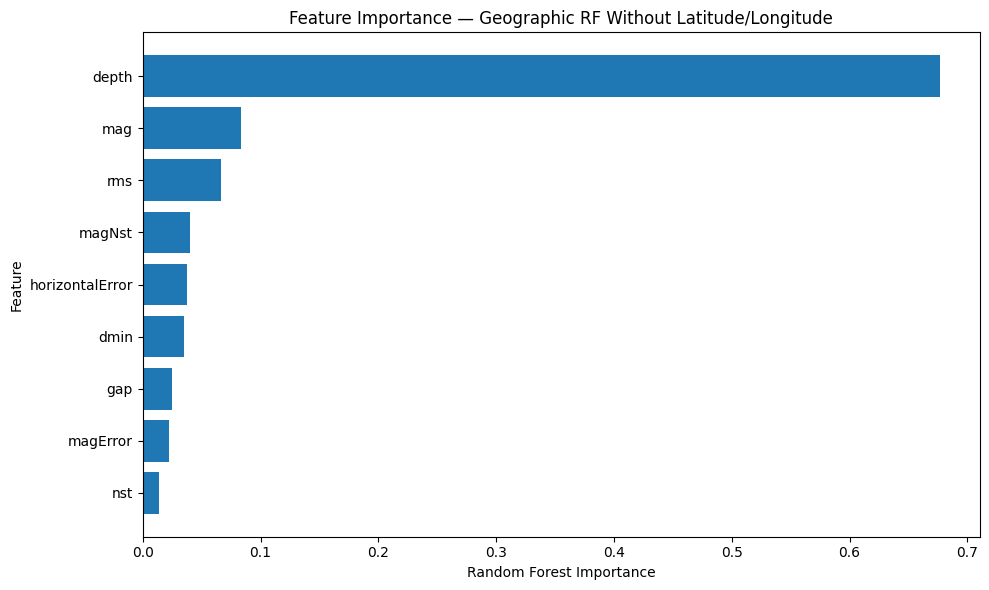

In [43]:
# ============================================================
# Cell 42 — Feature Importance
# Final Geographic RF WITHOUT Coordinates
# ============================================================

print("=" * 60)
print("FEATURE IMPORTANCE — GEOGRAPHIC RF WITHOUT COORDINATES")
print("=" * 60)

# ------------------------------------------------------------
# 1. Extract feature importance
# ------------------------------------------------------------

feature_importance_geo = pd.DataFrame({
    'Feature': geo_no_coord_features,
    'Importance': rf_geo_nc.feature_importances_
})

# Sort from most important to least important
feature_importance_geo = feature_importance_geo.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# 2. Display results
# ------------------------------------------------------------

print("\nFeature importance ranking:")
print(feature_importance_geo.to_string(index=False))

# ------------------------------------------------------------
# 3. Plot feature importance
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_geo['Feature'],
    feature_importance_geo['Importance']
)

plt.gca().invert_yaxis()

plt.xlabel("Random Forest Importance")
plt.ylabel("Feature")
plt.title(
    "Feature Importance — Geographic RF Without Latitude/Longitude"
)

plt.tight_layout()
plt.show()

In [44]:
# ============================================================
# Cell 43 — Geographic Holdout RF Using DEPTH ONLY
# ============================================================

print("=" * 60)
print("GEOGRAPHIC RF — DEPTH ONLY")
print("=" * 60)

# ------------------------------------------------------------
# 1. Select depth only from the SAME geographic split
# ------------------------------------------------------------

X_train_depth = X_train_geo[['depth']].copy()
X_test_depth = X_test_geo[['depth']].copy()

# ------------------------------------------------------------
# 2. Training-only median imputation
# ------------------------------------------------------------

depth_median = X_train_depth['depth'].median()

X_train_depth = X_train_depth.fillna(depth_median)
X_test_depth = X_test_depth.fillna(depth_median)

# ------------------------------------------------------------
# 3. Train RF
# ------------------------------------------------------------

rf_depth_geo = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    max_depth=None
)

rf_depth_geo.fit(
    X_train_depth,
    y_train_geo
)

# ------------------------------------------------------------
# 4. Test predictions
# ------------------------------------------------------------

depth_geo_probs = rf_depth_geo.predict_proba(
    X_test_depth
)[:, 1]

depth_geo_pred = (
    depth_geo_probs >= 0.5
).astype(int)

# ------------------------------------------------------------
# 5. Performance
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DEPTH-ONLY GEOGRAPHIC HOLDOUT")
print("=" * 60)

print(f"Accuracy  : {accuracy_score(y_test_geo, depth_geo_pred):.4f}")
print(f"Precision : {precision_score(y_test_geo, depth_geo_pred):.4f}")
print(f"Recall    : {recall_score(y_test_geo, depth_geo_pred):.4f}")
print(f"F1-score  : {f1_score(y_test_geo, depth_geo_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test_geo, depth_geo_probs):.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_geo,
        depth_geo_pred,
        target_names=label_encoder.classes_
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_geo,
        depth_geo_pred
    )
)

GEOGRAPHIC RF — DEPTH ONLY

DEPTH-ONLY GEOGRAPHIC HOLDOUT
Accuracy  : 0.8921
Precision : 0.9161
Recall    : 0.8914
F1-score  : 0.9036
ROC-AUC   : 0.9529

Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.86      0.89      0.88      3826
Quarry Blast       0.92      0.89      0.90      5009

    accuracy                           0.89      8835
   macro avg       0.89      0.89      0.89      8835
weighted avg       0.89      0.89      0.89      8835


Confusion Matrix:
[[3417  409]
 [ 544 4465]]


DEPTH DISTRIBUTION — EARTHQUAKES vs QUARRY BLASTS

Depth summary:
              count       mean  median        std    min      max
type                                                             
earthquake    20000  30.109989  10.000  61.118787 -3.760  649.610
quarry blast  20000  -0.550521  -0.578   1.128293 -2.076   21.544

DEPTH QUARTILES
               0.25    0.50    0.75
type                               
earthquake    4.900  10.000  32.705
quarry blast -0.952  -0.578  -0.210

NEAR-SURFACE EVENTS

Depth <= 0 km:
type
earthquake       3.195
quarry blast    94.840
Name: depth, dtype: float64

Depth <= 1 km:
type
earthquake       6.975
quarry blast    96.625
Name: depth, dtype: float64

Depth <= 2 km:
type
earthquake      12.140
quarry blast    97.265
Name: depth, dtype: float64

Depth <= 5 km:
type
earthquake      26.780
quarry blast    98.725
Name: depth, dtype: float64

Depth <= 10 km:
type
earthquake      52.375
quarry blast    99.970
Name: depth, dtype: float64


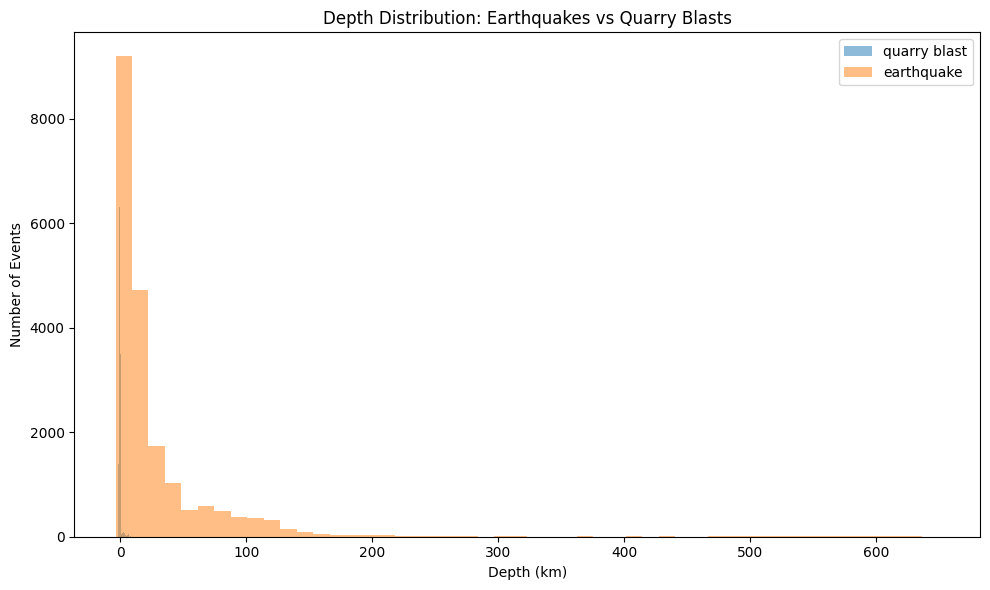

In [45]:
# ============================================================
# Cell 44 — Compare Depth Distributions
# Earthquakes vs Quarry Blasts
# ============================================================

print("=" * 60)
print("DEPTH DISTRIBUTION — EARTHQUAKES vs QUARRY BLASTS")
print("=" * 60)

depth_summary = df.groupby('type')['depth'].agg([
    'count',
    'mean',
    'median',
    'std',
    'min',
    'max'
])

print("\nDepth summary:")
print(depth_summary)

# ------------------------------------------------------------
# Depth quartiles
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DEPTH QUARTILES")
print("=" * 60)

depth_quartiles = df.groupby('type')['depth'].quantile(
    [0.25, 0.50, 0.75]
).unstack()

print(depth_quartiles)

# ------------------------------------------------------------
# Percentage of near-surface events
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("NEAR-SURFACE EVENTS")
print("=" * 60)

for threshold in [0, 1, 2, 5, 10]:

    print(f"\nDepth <= {threshold} km:")

    percentage = (
        df.groupby('type')['depth']
        .apply(lambda x: (x <= threshold).mean() * 100)
    )

    print(percentage)

# ------------------------------------------------------------
# Plot depth distributions
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

for event_type in df['type'].unique():

    subset = df[df['type'] == event_type]['depth'].dropna()

    plt.hist(
        subset,
        bins=50,
        alpha=0.5,
        label=event_type
    )

plt.xlabel("Depth (km)")
plt.ylabel("Number of Events")
plt.title("Depth Distribution: Earthquakes vs Quarry Blasts")
plt.legend()

plt.tight_layout()
plt.show()

In [46]:
# ============================================================
# Cell 45 — Shallow Earthquake Robustness Test
# ============================================================

print("=" * 60)
print("SHALLOW EARTHQUAKE vs QUARRY BLAST")
print("=" * 60)

# ------------------------------------------------------------
# Select earthquakes with depth <= 10 km
# ------------------------------------------------------------

shallow_eq = df[
    (df['type'] == 'earthquake') &
    (df['depth'] <= 10)
].copy()

# Keep all quarry blasts
all_blasts = df[
    df['type'] == 'quarry blast'
].copy()

# Combine
df_shallow = pd.concat(
    [shallow_eq, all_blasts],
    ignore_index=True
)

print("\nDataset size:")
print(df_shallow['type'].value_counts())

print(f"\nTotal events: {len(df_shallow)}")

print("\nDepth statistics:")
print(
    df_shallow.groupby('type')['depth'].agg([
        'count',
        'mean',
        'median',
        'std',
        'min',
        'max'
    ])
)

SHALLOW EARTHQUAKE vs QUARRY BLAST

Dataset size:
type
quarry blast    20000
earthquake      10475
Name: count, dtype: int64

Total events: 30475

Depth statistics:
              count      mean  median       std    min     max
type                                                          
earthquake    10475  4.971724   5.000  3.244387 -3.760  10.000
quarry blast  20000 -0.550521  -0.578  1.128293 -2.076  21.544


In [47]:
# ============================================================
# Cell 46 — Shallow-Earthquake Geographic Holdout
# ============================================================

print("=" * 60)
print("SHALLOW-EARTHQUAKE GEOGRAPHIC HOLDOUT")
print("=" * 60)

# ------------------------------------------------------------
# 1. Balance the two classes
# ------------------------------------------------------------

n_shallow_eq = len(shallow_eq)

shallow_blasts_balanced = all_blasts.sample(
    n=n_shallow_eq,
    random_state=SEED
)

df_shallow_balanced = pd.concat(
    [shallow_eq, shallow_blasts_balanced],
    ignore_index=True
)

# ------------------------------------------------------------
# 2. Create 5-degree geographic groups
# ------------------------------------------------------------

df_shallow_balanced['lat_grid'] = np.floor(
    df_shallow_balanced['latitude'] / 5
)

df_shallow_balanced['lon_grid'] = np.floor(
    df_shallow_balanced['longitude'] / 5
)

df_shallow_balanced['geo_group'] = (
    df_shallow_balanced['lat_grid'].astype(str)
    + "_"
    + df_shallow_balanced['lon_grid'].astype(str)
)

# ------------------------------------------------------------
# 3. Geographic train/test split
# ------------------------------------------------------------

geo_splitter_shallow = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=SEED
)

train_idx_shallow, test_idx_shallow = next(
    geo_splitter_shallow.split(
        df_shallow_balanced,
        df_shallow_balanced['type'],
        groups=df_shallow_balanced['geo_group']
    )
)

train_shallow = df_shallow_balanced.iloc[
    train_idx_shallow
].copy()

test_shallow = df_shallow_balanced.iloc[
    test_idx_shallow
].copy()

# ------------------------------------------------------------
# 4. Display split information
# ------------------------------------------------------------

print("\nTotal events:", len(df_shallow_balanced))

print("\nTrain events:", len(train_shallow))
print("Test events :", len(test_shallow))

print("\nTrain class distribution:")
print(train_shallow['type'].value_counts())

print("\nTest class distribution:")
print(test_shallow['type'].value_counts())

print("\nTrain geographic groups:",
      train_shallow['geo_group'].nunique())

print("Test geographic groups:",
      test_shallow['geo_group'].nunique())

overlap_shallow = (
    set(train_shallow['geo_group'])
    .intersection(set(test_shallow['geo_group']))
)

print("\nGeographic group overlap:", len(overlap_shallow))

SHALLOW-EARTHQUAKE GEOGRAPHIC HOLDOUT

Total events: 20950

Train events: 20540
Test events : 410

Train class distribution:
type
quarry blast    10475
earthquake      10065
Name: count, dtype: int64

Test class distribution:
type
earthquake    410
Name: count, dtype: int64

Train geographic groups: 276
Test geographic groups: 69

Geographic group overlap: 0


In [48]:
# ============================================================
# Cell 47 — Inspect Class Distribution Across Geographic Groups
# ============================================================

print("=" * 60)
print("GEOGRAPHIC GROUP CLASS DISTRIBUTION")
print("=" * 60)

geo_class_table = pd.crosstab(
    df_shallow_balanced['geo_group'],
    df_shallow_balanced['type']
)

# Make sure both columns exist
for class_name in ['earthquake', 'quarry blast']:
    if class_name not in geo_class_table.columns:
        geo_class_table[class_name] = 0

geo_class_table['total'] = (
    geo_class_table['earthquake']
    + geo_class_table['quarry blast']
)

geo_class_table['has_both_classes'] = (
    (geo_class_table['earthquake'] > 0)
    & (geo_class_table['quarry blast'] > 0)
)

print("\nTotal geographic groups:",
      len(geo_class_table))

print("\nGroups containing BOTH classes:",
      geo_class_table['has_both_classes'].sum())

print("\nEarthquake-only groups:",
      (geo_class_table['earthquake'] > 0).sum()
      - geo_class_table['has_both_classes'].sum())

print("\nQuarry-blast-only groups:",
      (geo_class_table['quarry blast'] > 0).sum()
      - geo_class_table['has_both_classes'].sum())

print("\nLargest geographic groups:")
print(
    geo_class_table
    .sort_values('total', ascending=False)
    .head(20)
)

print("\nClass totals:")
print(
    geo_class_table[
        ['earthquake', 'quarry blast']
    ].sum()
)

GEOGRAPHIC GROUP CLASS DISTRIBUTION

Total geographic groups: 345

Groups containing BOTH classes: 18

Earthquake-only groups: 325

Quarry-blast-only groups: 2

Largest geographic groups:
type        earthquake  quarry blast  total  has_both_classes
geo_group                                                    
6.0_-24.0         1121          3877   4998              True
7.0_-25.0         2095          2217   4312              True
7.0_-24.0         1591          1968   3559              True
9.0_-23.0           50           925    975              True
7.0_-20.0          263           423    686              True
12.0_-30.0         667             0    667             False
3.0_-32.0          565            51    616              True
6.0_-23.0           10           375    385              True
6.0_-20.0           12           362    374              True
12.0_-29.0         346             0    346             False
8.0_-23.0          277            67    344              True
12.0_-

In [49]:
# ============================================================
# Cell 48 — Incremental Feature-Group Experiment
# Original Geographic Holdout
# ============================================================

print("=" * 60)
print("INCREMENTAL FEATURE-GROUP EXPERIMENT")
print("=" * 60)

# ------------------------------------------------------------
# Feature groups
# ------------------------------------------------------------

feature_groups = {

    "Depth only": [
        "depth"
    ],

    "Depth + Magnitude": [
        "depth",
        "mag"
    ],

    "Depth + Magnitude + Quality": [
        "depth",
        "mag",
        "nst",
        "gap",
        "dmin",
        "rms",
        "horizontalError",
        "magError",
        "magNst"
    ],

    "All 9 coordinate-free features": [
        "depth",
        "mag",
        "nst",
        "gap",
        "dmin",
        "rms",
        "horizontalError",
        "magError",
        "magNst"
    ]
}

results_incremental = []

# ------------------------------------------------------------
# Train and evaluate each model
# ------------------------------------------------------------

for group_name, features in feature_groups.items():

    print(f"\nRunning: {group_name}")

    X_train = X_train_geo[features].copy()
    X_test = X_test_geo[features].copy()

    # Training-only median imputation
    train_medians = X_train.median()

    X_train = X_train.fillna(train_medians)
    X_test = X_test.fillna(train_medians)

    # Training-only scaling
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # RF
    rf = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1,
        max_depth=None
    )

    rf.fit(X_train_scaled, y_train_geo)

    # Predictions
    probabilities = rf.predict_proba(
        X_test_scaled
    )[:, 1]

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    results_incremental.append({
        "Feature Set": group_name,
        "Number of Features": len(features),
        "Accuracy": accuracy_score(
            y_test_geo,
            predictions
        ),
        "Precision": precision_score(
            y_test_geo,
            predictions
        ),
        "Recall": recall_score(
            y_test_geo,
            predictions
        ),
        "F1": f1_score(
            y_test_geo,
            predictions
        ),
        "ROC-AUC": roc_auc_score(
            y_test_geo,
            probabilities
        )
    })

# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

results_incremental_df = pd.DataFrame(
    results_incremental
)

print("\n" + "=" * 60)
print("RESULTS")
print("=" * 60)

print(
    results_incremental_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

INCREMENTAL FEATURE-GROUP EXPERIMENT

Running: Depth only

Running: Depth + Magnitude

Running: Depth + Magnitude + Quality

Running: All 9 coordinate-free features

RESULTS
                   Feature Set  Number of Features  Accuracy  Precision  Recall     F1  ROC-AUC
                    Depth only                   1    0.8926     0.9160  0.8924 0.9040   0.9534
             Depth + Magnitude                   2    0.9147     0.9299  0.9187 0.9243   0.9651
   Depth + Magnitude + Quality                   9    0.8824     0.9731  0.8151 0.8871   0.9679
All 9 coordinate-free features                   9    0.8824     0.9731  0.8151 0.8871   0.9679


In [50]:
# ============================================================
# Cell 49 — Leakage-Safe Threshold
# Depth + Magnitude Geographic RF
# ============================================================

print("=" * 60)
print("LEAKAGE-SAFE THRESHOLD — DEPTH + MAGNITUDE")
print("=" * 60)

# ------------------------------------------------------------
# 1. Select features
# ------------------------------------------------------------

features_dm = [
    'depth',
    'mag'
]

X_train_dm = X_train_geo[features_dm].copy()
X_test_dm = X_test_geo[features_dm].copy()

# ------------------------------------------------------------
# 2. Training-only imputation
# ------------------------------------------------------------

dm_medians = X_train_dm.median()

X_train_dm = X_train_dm.fillna(dm_medians)
X_test_dm = X_test_dm.fillna(dm_medians)

# ------------------------------------------------------------
# 3. Training-only scaling
# ------------------------------------------------------------

scaler_dm = StandardScaler()

X_train_dm_scaled = scaler_dm.fit_transform(X_train_dm)
X_test_dm_scaled = scaler_dm.transform(X_test_dm)

# ------------------------------------------------------------
# 4. 5-fold OOF predictions on TRAINING data only
# ------------------------------------------------------------

skf_dm = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

oof_dm_probs = np.zeros(len(y_train_geo))

for fold, (train_idx, val_idx) in enumerate(
    skf_dm.split(X_train_dm_scaled, y_train_geo),
    start=1
):

    rf_dm_fold = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1,
        max_depth=None
    )

    rf_dm_fold.fit(
        X_train_dm_scaled[train_idx],
        y_train_geo[train_idx]
    )

    oof_dm_probs[val_idx] = rf_dm_fold.predict_proba(
        X_train_dm_scaled[val_idx]
    )[:, 1]

    print(f"Fold {fold} completed")

# ------------------------------------------------------------
# 5. Select threshold using TRAINING OOF predictions only
# ------------------------------------------------------------

fpr_dm, tpr_dm, thresholds_dm = roc_curve(
    y_train_geo,
    oof_dm_probs
)

youden_j_dm = tpr_dm - fpr_dm

best_idx_dm = np.argmax(youden_j_dm)

best_threshold_dm = thresholds_dm[best_idx_dm]

oof_train_auc_dm = roc_auc_score(
    y_train_geo,
    oof_dm_probs
)

oof_train_tpr_dm = tpr_dm[best_idx_dm]
oof_train_fpr_dm = fpr_dm[best_idx_dm]

print("\nTraining OOF results:")
print(f"OOF ROC-AUC:       {oof_train_auc_dm:.4f}")
print(f"Selected threshold:{best_threshold_dm:.4f}")
print(f"OOF TPR:           {oof_train_tpr_dm:.4f}")
print(f"OOF FPR:           {oof_train_fpr_dm:.4f}")

# ------------------------------------------------------------
# 6. Train final RF on ALL geographic training data
# ------------------------------------------------------------

rf_dm = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    max_depth=None
)

rf_dm.fit(
    X_train_dm_scaled,
    y_train_geo
)

# ------------------------------------------------------------
# 7. Predict probabilities on untouched geographic test set
# ------------------------------------------------------------

dm_test_probs = rf_dm.predict_proba(
    X_test_dm_scaled
)[:, 1]

# ------------------------------------------------------------
# 8. Apply the FROZEN threshold
# ------------------------------------------------------------

dm_test_pred = (
    dm_test_probs >= best_threshold_dm
).astype(int)

# ------------------------------------------------------------
# 9. Final test metrics
# ------------------------------------------------------------

dm_accuracy = accuracy_score(
    y_test_geo,
    dm_test_pred
)

dm_precision = precision_score(
    y_test_geo,
    dm_test_pred,
    zero_division=0
)

dm_recall = recall_score(
    y_test_geo,
    dm_test_pred,
    zero_division=0
)

dm_f1 = f1_score(
    y_test_geo,
    dm_test_pred,
    zero_division=0
)

dm_roc_auc = roc_auc_score(
    y_test_geo,
    dm_test_probs
)

# ------------------------------------------------------------
# 10. Print final results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL GEOGRAPHIC TEST RESULTS")
print("DEPTH + MAGNITUDE")
print("=" * 60)

print(f"Accuracy:  {dm_accuracy:.4f}")
print(f"Precision: {dm_precision:.4f}")
print(f"Recall:    {dm_recall:.4f}")
print(f"F1 Score:  {dm_f1:.4f}")
print(f"ROC-AUC:   {dm_roc_auc:.4f}")

# ------------------------------------------------------------
# 11. Classification report
# ------------------------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        y_test_geo,
        dm_test_pred,
        target_names=["Earthquake", "Quarry Blast"],
        zero_division=0
    )
)

# ------------------------------------------------------------
# 12. Confusion matrix
# ------------------------------------------------------------

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test_geo,
        dm_test_pred
    )
)

print("\n" + "=" * 60)
print("CELL 49 COMPLETED")
print("=" * 60)

LEAKAGE-SAFE THRESHOLD — DEPTH + MAGNITUDE
Fold 1 completed
Fold 2 completed
Fold 3 completed
Fold 4 completed
Fold 5 completed

Training OOF results:
OOF ROC-AUC:       0.9915
Selected threshold:0.5216
OOF TPR:           0.9606
OOF FPR:           0.0265

FINAL GEOGRAPHIC TEST RESULTS
DEPTH + MAGNITUDE
Accuracy:  0.9154
Precision: 0.9347
Recall:    0.9148
F1 Score:  0.9246
ROC-AUC:   0.9651

Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.89      0.92      0.90      3826
Quarry Blast       0.93      0.91      0.92      5009

    accuracy                           0.92      8835
   macro avg       0.91      0.92      0.91      8835
weighted avg       0.92      0.92      0.92      8835

Confusion Matrix:
[[3506  320]
 [ 427 4582]]

CELL 49 COMPLETED


In [51]:
# ============================================================
# Cell 50 — Leakage-Safe Threshold
# Depth-Only Geographic RF
# ============================================================

print("=" * 60)
print("LEAKAGE-SAFE THRESHOLD — DEPTH ONLY")
print("=" * 60)

# ------------------------------------------------------------
# 1. Select depth only
# ------------------------------------------------------------

features_depth = ['depth']

X_train_depth = X_train_geo[features_depth].copy()
X_test_depth = X_test_geo[features_depth].copy()

# ------------------------------------------------------------
# 2. Training-only imputation
# ------------------------------------------------------------

depth_medians = X_train_depth.median()

X_train_depth = X_train_depth.fillna(depth_medians)
X_test_depth = X_test_depth.fillna(depth_medians)

# ------------------------------------------------------------
# 3. Training-only scaling
# ------------------------------------------------------------

scaler_depth = StandardScaler()

X_train_depth_scaled = scaler_depth.fit_transform(X_train_depth)
X_test_depth_scaled = scaler_depth.transform(X_test_depth)

# ------------------------------------------------------------
# 4. 5-fold OOF predictions on TRAINING data only
# ------------------------------------------------------------

skf_depth = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

oof_depth_probs = np.zeros(len(y_train_geo))

for fold, (train_idx, val_idx) in enumerate(
    skf_depth.split(X_train_depth_scaled, y_train_geo),
    start=1
):

    rf_depth_fold = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1,
        max_depth=None
    )

    rf_depth_fold.fit(
        X_train_depth_scaled[train_idx],
        y_train_geo[train_idx]
    )

    oof_depth_probs[val_idx] = rf_depth_fold.predict_proba(
        X_train_depth_scaled[val_idx]
    )[:, 1]

    print(f"Fold {fold} completed")

# ------------------------------------------------------------
# 5. Select threshold using TRAINING OOF predictions only
# ------------------------------------------------------------

fpr_depth, tpr_depth, thresholds_depth = roc_curve(
    y_train_geo,
    oof_depth_probs
)

youden_j_depth = tpr_depth - fpr_depth

best_idx_depth = np.argmax(youden_j_depth)

best_threshold_depth = thresholds_depth[best_idx_depth]

oof_train_auc_depth = roc_auc_score(
    y_train_geo,
    oof_depth_probs
)

oof_train_tpr_depth = tpr_depth[best_idx_depth]
oof_train_fpr_depth = fpr_depth[best_idx_depth]

print("\nTraining OOF results:")
print(f"OOF ROC-AUC:        {oof_train_auc_depth:.4f}")
print(f"Selected threshold: {best_threshold_depth:.4f}")
print(f"OOF TPR:            {oof_train_tpr_depth:.4f}")
print(f"OOF FPR:            {oof_train_fpr_depth:.4f}")

# ------------------------------------------------------------
# 6. Train final RF on ALL geographic training data
# ------------------------------------------------------------

rf_depth = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    max_depth=None
)

rf_depth.fit(
    X_train_depth_scaled,
    y_train_geo
)

# ------------------------------------------------------------
# 7. Predict untouched geographic test set
# ------------------------------------------------------------

depth_test_probs = rf_depth.predict_proba(
    X_test_depth_scaled
)[:, 1]

# ------------------------------------------------------------
# 8. Apply frozen threshold
# ------------------------------------------------------------

depth_test_pred = (
    depth_test_probs >= best_threshold_depth
).astype(int)

# ------------------------------------------------------------
# 9. Final test metrics
# ------------------------------------------------------------

depth_accuracy = accuracy_score(
    y_test_geo,
    depth_test_pred
)

depth_precision = precision_score(
    y_test_geo,
    depth_test_pred,
    zero_division=0
)

depth_recall = recall_score(
    y_test_geo,
    depth_test_pred,
    zero_division=0
)

depth_f1 = f1_score(
    y_test_geo,
    depth_test_pred,
    zero_division=0
)

depth_roc_auc = roc_auc_score(
    y_test_geo,
    depth_test_probs
)

# ------------------------------------------------------------
# 10. Print final results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL GEOGRAPHIC TEST RESULTS")
print("DEPTH ONLY")
print("=" * 60)

print(f"Accuracy:  {depth_accuracy:.4f}")
print(f"Precision: {depth_precision:.4f}")
print(f"Recall:    {depth_recall:.4f}")
print(f"F1 Score:  {depth_f1:.4f}")
print(f"ROC-AUC:   {depth_roc_auc:.4f}")

# ------------------------------------------------------------
# 11. Classification report
# ------------------------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        y_test_geo,
        depth_test_pred,
        target_names=["Earthquake", "Quarry Blast"],
        zero_division=0
    )
)

# ------------------------------------------------------------
# 12. Confusion matrix
# ------------------------------------------------------------

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test_geo,
        depth_test_pred
    )
)

print("\n" + "=" * 60)
print("CELL 50 COMPLETED")
print("=" * 60)

LEAKAGE-SAFE THRESHOLD — DEPTH ONLY
Fold 1 completed
Fold 2 completed
Fold 3 completed
Fold 4 completed
Fold 5 completed

Training OOF results:
OOF ROC-AUC:        0.9835
Selected threshold: 0.6460
OOF TPR:            0.9617
OOF FPR:            0.0385

FINAL GEOGRAPHIC TEST RESULTS
DEPTH ONLY
Accuracy:  0.9007
Precision: 0.9377
Recall:    0.8836
F1 Score:  0.9099
ROC-AUC:   0.9534

Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.86      0.92      0.89      3826
Quarry Blast       0.94      0.88      0.91      5009

    accuracy                           0.90      8835
   macro avg       0.90      0.90      0.90      8835
weighted avg       0.90      0.90      0.90      8835

Confusion Matrix:
[[3532  294]
 [ 583 4426]]

CELL 50 COMPLETED


In [52]:
# ============================================================
# Cell 51 — Temporal Holdout
# Depth + Magnitude Random Forest
# Train: 2000–2019
# Test:  2020–2024
# ============================================================

print("=" * 60)
print("TEMPORAL HOLDOUT — DEPTH + MAGNITUDE")
print("=" * 60)

# ------------------------------------------------------------
# 1. Use existing temporal split
# ------------------------------------------------------------

print("\nTraining period:")
print(
    train_temporal['event_year'].min(),
    "to",
    train_temporal['event_year'].max()
)

print("Testing period:")
print(
    test_temporal['event_year'].min(),
    "to",
    test_temporal['event_year'].max()
)

print("\nTraining samples:", len(train_temporal))
print("Test samples:", len(test_temporal))

print("\nTraining class distribution:")
print(train_temporal['Type'].value_counts())

print("\nTest class distribution:")
print(test_temporal['Type'].value_counts())

# ------------------------------------------------------------
# 2. Select only Depth + Magnitude
# ------------------------------------------------------------

features_temporal_dm = [
    'depth',
    'mag'
]

X_train_time_dm = train_temporal[
    features_temporal_dm
].copy()

X_test_time_dm = test_temporal[
    features_temporal_dm
].copy()

# ------------------------------------------------------------
# 3. Create labels
# ------------------------------------------------------------

y_train_time = (
    train_temporal['Type']
    .map({
        'Earthquake': 0,
        'Quarry Blast': 1
    })
    .values
)

y_test_time = (
    test_temporal['Type']
    .map({
        'Earthquake': 0,
        'Quarry Blast': 1
    })
    .values
)

# ------------------------------------------------------------
# 4. Training-only imputation
# ------------------------------------------------------------

time_dm_medians = X_train_time_dm.median()

X_train_time_dm = X_train_time_dm.fillna(
    time_dm_medians
)

X_test_time_dm = X_test_time_dm.fillna(
    time_dm_medians
)

# ------------------------------------------------------------
# 5. Training-only scaling
# ------------------------------------------------------------

scaler_time_dm = StandardScaler()

X_train_time_dm_scaled = scaler_time_dm.fit_transform(
    X_train_time_dm
)

X_test_time_dm_scaled = scaler_time_dm.transform(
    X_test_time_dm
)

# ------------------------------------------------------------
# 6. 5-fold OOF predictions on training period only
# ------------------------------------------------------------

skf_time_dm = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

oof_time_dm_probs = np.zeros(
    len(y_train_time)
)

for fold, (train_idx, val_idx) in enumerate(
    skf_time_dm.split(
        X_train_time_dm_scaled,
        y_train_time
    ),
    start=1
):

    rf_time_dm_fold = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1,
        max_depth=None
    )

    rf_time_dm_fold.fit(
        X_train_time_dm_scaled[train_idx],
        y_train_time[train_idx]
    )

    oof_time_dm_probs[val_idx] = (
        rf_time_dm_fold
        .predict_proba(
            X_train_time_dm_scaled[val_idx]
        )[:, 1]
    )

    print(f"Fold {fold} completed")

# ------------------------------------------------------------
# 7. Select threshold using training OOF only
# ------------------------------------------------------------

fpr_time_dm, tpr_time_dm, thresholds_time_dm = roc_curve(
    y_train_time,
    oof_time_dm_probs
)

youden_j_time_dm = (
    tpr_time_dm - fpr_time_dm
)

best_idx_time_dm = np.argmax(
    youden_j_time_dm
)

best_threshold_time_dm = (
    thresholds_time_dm[best_idx_time_dm]
)

oof_auc_time_dm = roc_auc_score(
    y_train_time,
    oof_time_dm_probs
)

print("\nTraining OOF results:")
print(
    f"OOF ROC-AUC:        {oof_auc_time_dm:.4f}"
)

print(
    f"Selected threshold: {best_threshold_time_dm:.4f}"
)

print(
    f"OOF TPR:            {tpr_time_dm[best_idx_time_dm]:.4f}"
)

print(
    f"OOF FPR:            {fpr_time_dm[best_idx_time_dm]:.4f}"
)

# ------------------------------------------------------------
# 8. Train final model on ALL 2000–2019 data
# ------------------------------------------------------------

rf_time_dm = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    max_depth=None
)

rf_time_dm.fit(
    X_train_time_dm_scaled,
    y_train_time
)

# ------------------------------------------------------------
# 9. Predict untouched 2020–2024 data
# ------------------------------------------------------------

time_dm_test_probs = (
    rf_time_dm
    .predict_proba(
        X_test_time_dm_scaled
    )[:, 1]
)

# ------------------------------------------------------------
# 10. Apply frozen threshold
# ------------------------------------------------------------

time_dm_test_pred = (
    time_dm_test_probs >= best_threshold_time_dm
).astype(int)

# ------------------------------------------------------------
# 11. Final temporal test metrics
# ------------------------------------------------------------

time_dm_accuracy = accuracy_score(
    y_test_time,
    time_dm_test_pred
)

time_dm_precision = precision_score(
    y_test_time,
    time_dm_test_pred,
    zero_division=0
)

time_dm_recall = recall_score(
    y_test_time,
    time_dm_test_pred,
    zero_division=0
)

time_dm_f1 = f1_score(
    y_test_time,
    time_dm_test_pred,
    zero_division=0
)

time_dm_roc_auc = roc_auc_score(
    y_test_time,
    time_dm_test_probs
)

# ------------------------------------------------------------
# 12. Final results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL TEMPORAL TEST RESULTS")
print("DEPTH + MAGNITUDE")
print("=" * 60)

print(
    f"Accuracy:  {time_dm_accuracy:.4f}"
)

print(
    f"Precision: {time_dm_precision:.4f}"
)

print(
    f"Recall:    {time_dm_recall:.4f}"
)

print(
    f"F1 Score:  {time_dm_f1:.4f}"
)

print(
    f"ROC-AUC:   {time_dm_roc_auc:.4f}"
)

# ------------------------------------------------------------
# 13. Classification report
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test_time,
        time_dm_test_pred,
        target_names=[
            "Earthquake",
            "Quarry Blast"
        ],
        zero_division=0
    )
)

# ------------------------------------------------------------
# 14. Confusion matrix
# ------------------------------------------------------------

print("Confusion Matrix:")

print(
    confusion_matrix(
        y_test_time,
        time_dm_test_pred
    )
)

print("\n" + "=" * 60)
print("CELL 51 COMPLETED")
print("=" * 60)

TEMPORAL HOLDOUT — DEPTH + MAGNITUDE

Training period:
2000 to 2019
Testing period:
2020 to 2024

Training samples: 29742
Test samples: 10258

Training class distribution:
Type
Earthquake      16000
Quarry Blast    13742
Name: count, dtype: int64

Test class distribution:
Type
Quarry Blast    6258
Earthquake      4000
Name: count, dtype: int64
Fold 1 completed
Fold 2 completed
Fold 3 completed
Fold 4 completed
Fold 5 completed

Training OOF results:
OOF ROC-AUC:        0.9876
Selected threshold: 0.5350
OOF TPR:            0.9527
OOF FPR:            0.0309

FINAL TEMPORAL TEST RESULTS
DEPTH + MAGNITUDE
Accuracy:  0.9167
Precision: 0.9799
Recall:    0.8814
F1 Score:  0.9281
ROC-AUC:   0.9792

Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.84      0.97      0.90      4000
Quarry Blast       0.98      0.88      0.93      6258

    accuracy                           0.92     10258
   macro avg       0.91      0.93      0.91     10258
weigh

In [53]:
# ============================================================
# TEMPORAL HOLDOUT — FINAL TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Train final model on ALL training-period data
rf_time_dm.fit(X_train_time_dm_scaled, y_train_time)

# Predict on untouched 2020–2024 test set
time_dm_test_probs = rf_time_dm.predict_proba(X_test_time_dm_scaled)[:, 1]

# Use threshold selected ONLY from training OOF predictions
time_dm_test_pred = (
    time_dm_test_probs >= best_threshold_time_dm
).astype(int)

# Metrics
time_accuracy = accuracy_score(y_test_time, time_dm_test_pred)
time_precision = precision_score(y_test_time, time_dm_test_pred)
time_recall = recall_score(y_test_time, time_dm_test_pred)
time_f1 = f1_score(y_test_time, time_dm_test_pred)
time_auc = roc_auc_score(y_test_time, time_dm_test_probs)

print("\n" + "="*60)
print("FINAL TEMPORAL HOLDOUT RESULTS")
print("="*60)

print(f"Threshold:       {best_threshold_time_dm:.4f}")
print(f"Accuracy:        {time_accuracy:.4f}")
print(f"Precision:       {time_precision:.4f}")
print(f"Recall:          {time_recall:.4f}")
print(f"F1-score:        {time_f1:.4f}")
print(f"ROC-AUC:         {time_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_time,
        time_dm_test_pred,
        target_names=["Earthquake", "Quarry Blast"]
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test_time, time_dm_test_pred))


FINAL TEMPORAL HOLDOUT RESULTS
Threshold:       0.5350
Accuracy:        0.9167
Precision:       0.9799
Recall:          0.8814
F1-score:        0.9281
ROC-AUC:         0.9792

Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.84      0.97      0.90      4000
Quarry Blast       0.98      0.88      0.93      6258

    accuracy                           0.92     10258
   macro avg       0.91      0.93      0.91     10258
weighted avg       0.93      0.92      0.92     10258

Confusion Matrix:
[[3887  113]
 [ 742 5516]]


In [54]:
# #-------Cell 35---------#
# #-----Inspect geographic distribution by class-----#

# print("=" * 60)
# print("Geographic Distribution of Events")
# print("=" * 60)

# # Basic geographic summary by event type
# geo_summary = df.groupby('Type')[['latitude', 'longitude']].agg(
#     ['min', 'max', 'mean', 'std']
# )

# print("\nLatitude/Longitude summary by event type:")
# display(geo_summary)

# # Number of unique exact coordinates by class
# unique_locations = df.groupby('Type').apply(
#     lambda x: x[['latitude', 'longitude']].drop_duplicates().shape[0]
# )

# print("\nUnique exact coordinate pairs by event type:")
# print(unique_locations)

# # Approximate geographic cells
# # Rounding to 1 decimal degree gives roughly 10–11 km cells
# df['lat_grid'] = df['latitude'].round(1)
# df['lon_grid'] = df['longitude'].round(1)

# df['geo_cell'] = (
#     df['lat_grid'].astype(str) + "_" +
#     df['lon_grid'].astype(str)
# )

# geo_cells = df.groupby('Type')['geo_cell'].nunique()

# print("\nUnique ~10-km geographic cells by event type:")
# print(geo_cells)

# # How many events occur in geographic cells shared by both classes?
# cell_class_counts = (
#     df.groupby(['geo_cell', 'Type'])
#       .size()
#       .unstack(fill_value=0)
# )

# shared_cells = cell_class_counts[
#     (cell_class_counts > 0).all(axis=1)
# ]

# print(f"\nTotal geographic cells: {df['geo_cell'].nunique()}")
# print(f"Cells containing BOTH classes: {len(shared_cells)}")

# print("\nTop 10 geographic cells by number of events:")
# print(
#     df['geo_cell']
#       .value_counts()
#       .head(10)
# )

In [55]:
# #-------Cell 36---------#
# #-----Physical features without latitude and longitude-----#

# physical_no_geo = [
#     'depth',
#     'mag',
#     'nst',
#     'gap',
#     'dmin',
#     'rms',
#     'horizontalError',
#     'depthError',
#     'magError',
#     'magNst'
# ]

# no_geo_result = run_experiment(
#     physical_no_geo,
#     "F: Physical features without latitude and longitude"
# )

# print("\nNo-geographic-feature experiment completed.")

In [56]:
# #-------Cell 37---------#
# #-----Create geographic groups for spatial holdout-----#

# # Use approximately 5-degree geographic cells.
# # Entire cells will later be kept together so that
# # train and test do not share the same broad geographic region.

# df['geo_lat_group'] = np.floor(df['latitude'] / 5) * 5
# df['geo_lon_group'] = np.floor(df['longitude'] / 5) * 5

# df['geo_group'] = (
#     df['geo_lat_group'].astype(str) + "_" +
#     df['geo_lon_group'].astype(str)
# )

# print("=" * 60)
# print("Geographic Grouping")
# print("=" * 60)

# print(f"\nTotal geographic groups: {df['geo_group'].nunique()}")

# print("\nGeographic groups by event type:")
# print(
#     df.groupby('Type')['geo_group'].nunique()
# )

# print("\nLargest geographic groups:")
# print(
#     df['geo_group']
#       .value_counts()
#       .head(15)
# )

# # Check class composition of geographic groups
# group_class_counts = (
#     df.groupby(['geo_group', 'Type'])
#       .size()
#       .unstack(fill_value=0)
# )

# print("\nNumber of groups containing both classes:")
# print(
#     ((group_class_counts > 0).all(axis=1)).sum()
# )

# print("\nNumber of groups containing only one class:")
# print(
#     ((group_class_counts > 0).sum(axis=1) == 1).sum()
# )

In [57]:
# #-------Cell 38---------#
# #-----Inspect mixed geographic groups-----#

# mixed_geo_groups = group_class_counts[
#     (group_class_counts > 0).all(axis=1)
# ].copy()

# mixed_geo_groups['Total'] = mixed_geo_groups.sum(axis=1)

# mixed_geo_groups = mixed_geo_groups.sort_values(
#     'Total',
#     ascending=False
# )

# print("=" * 60)
# print("Mixed Geographic Groups")
# print("=" * 60)

# print(
#     mixed_geo_groups.to_string()
# )

# print("\nTotal mixed groups:", len(mixed_geo_groups))

# print("\nTotal events in mixed groups:")
# print(
#     mixed_geo_groups[['Earthquake', 'Quarry Blast']].sum()
# )

In [58]:
# #-------Cell 39---------#
# #-----Check dataset class counts and yearly distribution-----#

# print("=" * 60)
# print("Dataset Sampling Audit")
# print("=" * 60)

# print("\nTotal events by class:")
# print(df['Type'].value_counts())

# print("\nEvents by year and class:")

# year_class_counts = pd.crosstab(
#     df['event_year'] if 'event_year' in df.columns
#     else pd.to_datetime(df['time']).dt.year,
#     df['Type']
# )

# print(year_class_counts.to_string())

# print("\nMaximum events from any single year:")
# print(year_class_counts.max())

# print("\nMinimum events from any single year:")
# print(year_class_counts.min())